Báo cáo Phân tích Khám phá **EDA** – Dự đoán Customer Churn
---
**Mô tả dự án**  
- Dự án thực hiện Phân tích Khám phá Dữ liệu **EDA - Exploratory Data Analysis** và Kỹ thuật Đặc trưng **Feature Engineering** chuyên sâu cho bài toán dự báo rủi ro rời bỏ dịch vụ của khách hàng **Customer Churn**. Tập dữ liệu được khai thác từ **Kaggle Playground Series** – tổ hợp các cuộc thi **Machine Learning** được tổ chức hàng tháng. Dự án không chỉ dừng lại ở việc quan sát thống kê mô tả mà còn biến đổi dữ liệu thô thành một không gian vector tối ưu nhất cho các thuật toán học máy.

**Mục tiêu cốt lõi**
- Kiểm định Chất lượng Dữ liệu **Data Quality Assessment**: Kiểm tra tính hợp lệ của hệ thống các đặc trưng định lượng và định tính, xử lí các điểm ngoại lai **Outliers** với mục đích đảm bảo đầu vào mô hình.
- Khám phá phân phối & động cơ rời bỏ **Univariate & Bivariate Analysis**: Khảo sát phân phối các biến định lượng, phân bố các đặc trưng định tính và sự mất cân bằng dữ liệu của biến mục tiêu, qua đó phân tích tác động qua lại của các đặc trưng gốc và ảnh hưởng của chúng lên quyết định rời bỏ dịch vụ của khách hàng.
- Thiết kế đặc trưng **Feature Engineering**: Khai thác tối đa **Insight** từ các phân tích để xây dựng các đặc trưng mới nhằm tối ưu mô hình.
- Tính toán mức độ tương quan toàn cục **Global Correlation Analysis** thông qua các hệ quy chiếu toán học **Pearson**, **Spearman**, **Cramer's V** để sàng lọc đa cộng tuyến và lượng hóa sức mạnh phân tách của toàn bộ không gian đặc trưng.

**Định hướng kết quả**
- Thiết lập Bảng xếp hạng Sức mạnh Đặc trưng **Feature Superiority Ranking** dựa trên các bằng chứng thống kê.
- Loại bỏ triệt để các biến nhiễu, biến gốc bị thay thế và bẫy đa cộng tuyến. Đóng gói thành công một Cấu trúc bộ dữ liệu chuẩn **Model Schema** tinh gọn, sẵn sàng chuyển giao cho hệ thống Pipeline **MLOps** để huấn luyện các mô hình **Gradient Boosting** đạt hiệu suất tối đa.
---

 Các thành viên nhóm 14
---
| Tên          | Mã số sinh viên    |
|----------------|--------------|
| Nguyễn Lan Anh       | 24280006      |
| Lê Văn Đức (Trưởng nhóm) | 24280010|
| Trần Quang Huy| 24280015|
| Phạm Tiến Phát    | 24280018 | 
|    Hoàng Gia Bảo | 24280049      |
| Đặng Hoàng Khang| 24280076|
| Nguyễn Tiến Phát | 24280093|

# 0. Setup môi trường làm việc (Environment Setup)

## 0.1 Import thư viện (Library Imports)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import matplotlib.patches as mpatches
import scipy.stats as ss

In [2]:
from IPython.display import display
from scipy.stats import chi2_contingency


## 0.2 Cấu hình hiển thị và đồ thị (Display & Styling Configuration)

In [3]:
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)
sns.set_theme(style="whitegrid")

## 0.3 Tải dữ liệu cần thiết (Data Loading)

In [4]:
print("Đang tải dữ liệu từ Kaggle...")
path = kagglehub.competition_download("playground-series-s6e3")
df_train = pd.read_csv(os.path.join(path, 'train.csv'))

print(f"Tải thành công!\nKích thước file 'train.csv': {df_train.shape[0]:,} hàng, {df_train.shape[1]} cột.")

Đang tải dữ liệu từ Kaggle...
Tải thành công!
Kích thước file 'train.csv': 594,194 hàng, 21 cột.


**Note:** Thực hiện clone `df_train` và làm việc trên bộ dữ liệu vừa tạo `df_train_copy` nhằm giữ nguyên tính toàn vẹn của dữ liệu gốc.

In [5]:
df_train_copy = df_train.copy()

# 1. Tiền xử lí dữ liệu (Data Preprocessing)

**Thông qua các bước sau để thực hiện làm sạch và chuẩn hóa dữ liệu** 
1. Kiểm tra tổng quan dữ liệu **Overview** 
2. Kiểm tra dữ liệu rỗng **Completeness Check**
3. Kiểm tra tính trùng lặp **Validity & Consistency Check**


In [6]:
print("1. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):")
df_train_copy.info()

1. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):
<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-nul

In [7]:
print("2. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):")
if df_train_copy.isnull().sum().sum() == 0:
    print("Không có dữ liệu rỗng trong tập dữ liệu training.csv.")
else:
    print("Tồn tại dữ liệu rỗng trong tập dữ liệu training.csv, cụ thể phân bố dữ liệu rỗng:")
    print(df_train_copy.isnull().sum())
print("\n3. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):")
if df_train_copy.duplicated().sum() == 0:
    print("Không có dữ liệu trùng lặp trong tập dữ liệu.")
else:
    print("Tồn tại", df_train_copy.duplicated().sum(), "hàng dữ liệu trùng lặp trong tập dữ liệu.")

2. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):
Không có dữ liệu rỗng trong tập dữ liệu training.csv.

3. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):
Không có dữ liệu trùng lặp trong tập dữ liệu.


# 2. Khảo sát dữ liệu tổng quan (Dataset Overview)

## 2.1 Mô tả sơ bộ (Preliminary Overview)

**Note:** Tìm hiểu sơ bộ dữ liệu thông qua những dòng đầu tiên.

In [8]:
df_train_copy.head().style.hide(axis='index')

id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.100000,1653.850000,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.500000,3778.200000,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.400000,5841.350000,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.700000,70.700000,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.450000,70.450000,Yes


| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `id` | int64 | Mã định danh của khách hàng |
| `gender` | object | Giới tính |
| `SeniorCitizen` | int64 | Khách hàng có là người cao tuổi **$\geqslant 65$ tuổi**?|
| `Partner` | object | Khách hàng có sống chung với vợ/chồng?|
| `Dependents` | object | Khách hàng có người phụ thuộc tài chính?|
| `tenure` | int64 | `Thời gian sử dụng dịch vụ`: Thời gian khách hàng gắn bó và sử dụng dịch vụ, tính theo tháng|
| `PhoneService` | object | Khách hàng có đăng ký dịch vụ điện thoại?|
| `MultipleLines` | object | Khách hàng có sử dụng nhiều đường dây điện thoại cùng lúc?|
| `InternetService` | object | Loại dịch vụ Internet mà khách hàng đang sử dụng|
| `OnlineSecurity` | object | Khách hàng có đăng ký gói bảo mật mạng trực tuyến?|
| `OnlineBackup` | object | Khách hàng có đăng ký gói sao lưu dữ liệu đám mây?|
| `DeviceProtection` | object | Khách hàng có mua gói bảo vệ thiết bị?|
| `TechSupport` | object | Khách hàng có đăng ký dịch vụ hỗ trợ kỹ thuật?|
| `StreamingTV` | object | Khách hàng có sử dụng Internet để xem truyền hình?|
| `StreamingMovies` | object | Khách hàng có sử dụng Internet để xem phim trực tuyến?|
| `Contract`| object | Loại hợp đồng thanh toán khách hàng đã ký?|
| `PaperlessBilling` | object | Khách hàng có nhận hóa đơn điện tử?|
| `PaymentMethod` | object | Phương thức thanh toán|
| `MonthlyCharges` | float64 | `Cước phí theo tháng`, ghi nhận vào tháng cuối cùng khảo sát được|
| `TotalCharges` | float64 | `Tổng cước phí`, ghi nhận trong suốt quá trình khảo sát|
| `Churn` | object | `Biến mục tiêu (Target)`: Đến thời điểm kết thúc khảo sát, khách hàng có rời bỏ dịch vụ không?|

**Note:** Biến đổi `SeniorCitizen` về hai giá trị *Yes/No* thay cho *1/0* như trong dữ liệu gốc để đồng nhất so với các biến nhị phân khác. Khi thực hiện **Machine Learning** ta trả giá trị này về giá trị nhị phân tương ứng của chúng.

In [9]:
df_train_copy['SeniorCitizen'] = df_train_copy['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

## 2.2 Phân nhóm và Xác định vai trò của biến (Feature Role & Type Classification)
Thực hiện phân nhóm các biến theo vai trò của chúng, cụ thể
- *Biến định danh* **Identifiers**
- *Biến định lượng* **Numerical Features**
- *Biến định tính* **Categorical Features**
- *Biến mục tiêu* **Target** là mục tiêu của dự án này, biến `Churn`


**Note:** *Biến định danh* như tên gọi, định danh một đối tượng, không mang ý nghĩa về thống kê nhưng rất có ích trong quá trình kiểm tra các dữ liệu trống và dữ liệu lỗi giai đoạn tiền xử lí dữ liệu. 

In [10]:
identifier_data= df_train_copy['id']
identifier_features = [identifier_data.name]

print(f'Có {len(identifier_features)} biến định danh:', end=" ")
print(identifier_features)


Có 1 biến định danh: ['id']


**Note:** Biến định lượng biểu diễn các giá trị đo lường bằng số cụ thể, mang ý nghĩa thống kê rõ rệt. Nhóm biến này giúp ta xác định được các chỉ số mô tả quan trọng như giá trị trung bình, độ phân tán và hình dáng phân phối của dữ liệu trước khi đi sâu vào phân tích.

In [11]:
numerical_data = df_train_copy.select_dtypes(include='number').drop('id', axis=1, errors='ignore')
numerical_features = numerical_data.columns.tolist()

print(f'Có {len(numerical_features)} biến định lượng:', end=" ")
print(numerical_features)

Có 3 biến định lượng: ['tenure', 'MonthlyCharges', 'TotalCharges']


**Note:** Biến định tính dùng để phân loại dữ liệu dựa trên các đặc tính hoặc danh mục cụ thể. Việc gom nhóm biến này giúp ta trực quan hóa được tỉ lệ phân bố, cấu trúc của tập dữ liệu và so sánh sự khác biệt giữa các nhóm khách hàng một cách trực quan.

In [12]:
categorical_data=df_train_copy.select_dtypes(include=['object','str']).drop('Churn', axis=1, errors='ignore')
categorical_features=categorical_data.columns.tolist()

print(f'Có {len(categorical_features)} biến định tính', end=" ")
print(categorical_features)

Có 16 biến định tính ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Note:** Biến mục tiêu `Churn` được tách riêng trong giai đoạn đầu nhằm mô tả và trực quan hóa độc lập các nhóm đặc trưng. Sau khi định hình được bức tranh tổng quan, biến này sẽ được kết hợp với các đặc trưng còn lại nhằm khám phá các quy luật ẩn.

In [13]:
target_data = df_train_copy['Churn']        
target_features = [target_data.name]
print(f'Có {len(target_features)} biến mục tiêu', end=" ")
print(target_features)

Có 1 biến mục tiêu ['Churn']


# 3. Đánh giá chất lượng dữ liệu (Data Quality Assessment).

## 3.1 Kiểm tra tính hợp lệ của đặc trưng định lượng (Numerical Features Sanity Check)

**Note:** Mục tiêu của phần này là kiểm chứng tính hợp lệ về mặt toán học và logic nghiệp vụ của các đặc trưng định lượng, nhằm phát hiện và xử lý kịp thời nội dung chứa giá trị vô lý.

**Note:** Hàm được sử dụng để rà soát lỗi logic của các đặc trưng định lượng
   - Thời gian sử dụng dịch vụ **tenure** yêu cầu là số nguyên dương.
   - Giá cước hàng tháng **MonthlyCharges** yêu cầu không âm.
   - Tổng cước **TotalCharges** yêu cầu không âm.

In [14]:

checks = {
        "Số tháng sử dụng dịch vụ không nguyên dương": int(((df_train_copy["tenure"] <= 0) | (df_train_copy["tenure"] % 1 != 0)).sum()),
        "Giá cước hàng tháng không dương": int((df_train_copy["MonthlyCharges"] <= 0).sum()),
        "Tổng cước không dương": int((pd.to_numeric(df_train_copy["TotalCharges"], errors='coerce') <= 0).sum())
}
print(f"--- Kiểm tra đặc trưng định lượng ---")
display(pd.Series(checks).to_frame("Số lỗi phát hiện tương ứng"))

--- Kiểm tra đặc trưng định lượng ---


,Số lỗi phát hiện tương ứng
Số tháng sử dụng dịch vụ không nguyên dương,0
Giá cước hàng tháng không dương,0
Tổng cước không dương,0


**Nhận xét:**
- Kết quả đồng loạt bằng **0** chứng minh các biến định lượng trong tập dữ liệu hoàn toàn hợp lệ về mặt toán học lẫn logic nghiệp vụ, không tồn tại trường hợp thời gian gắn bó tenure bị âm, bị lẻ số thập phân, hay cước phí hàng tháng/tổng cước nhỏ hơn hoặc bằng **0**.
- Vì tính hợp lí và logic của dữ liệu định lượng được đảm bảo tuyệt đối, ta không thực hiện các thao tác xử lý lỗi như ép kiểu, xóa bỏ dòng lỗi hay dùng các kỹ thuật gán lại giá trị **imputation** trước khi tiến hành phân tích.
- Quá trình kiến tạo đặc trưng **Feature Engineering** được đảm bảo không xảy ra các lỗi chia cho không **ZeroDivisionError** hoặc lỗi sinh ra các giá trị vô cực **Inf** được đảm bảo không xảy ra, tránh gây sai lệch mô hình ở mức tối đa.

## 3.2. Khảo sát phân phối và Kiểm soát điểm ngoại lai (Outlier Detection)

**Note:** Phân tích và trực quan hóa các đặc trưng định lượng bằng đồ thị Boxplot nhằm tìm kiếm và xử lý **capping** các giá trị ngoại lai nếu xuất hiện, tránh làm nhiễu mô hình dự đoán.

**Note:** Đổi tên đặc trưng với mục đích hiển thị.

In [15]:
column_mapping = {
    'tenure': 'Thời gian sử dụng dịch vụ',
    'MonthlyCharges': 'Cước phí hàng tháng',
    'TotalCharges': 'Tổng cước phí'
}

def get_name(col_name):
    return column_mapping.get(col_name, col_name)

**Note:** Trực quan hóa phân bố khách hàng theo các đặc trưng định lượng bằng đồ thị Boxplot.

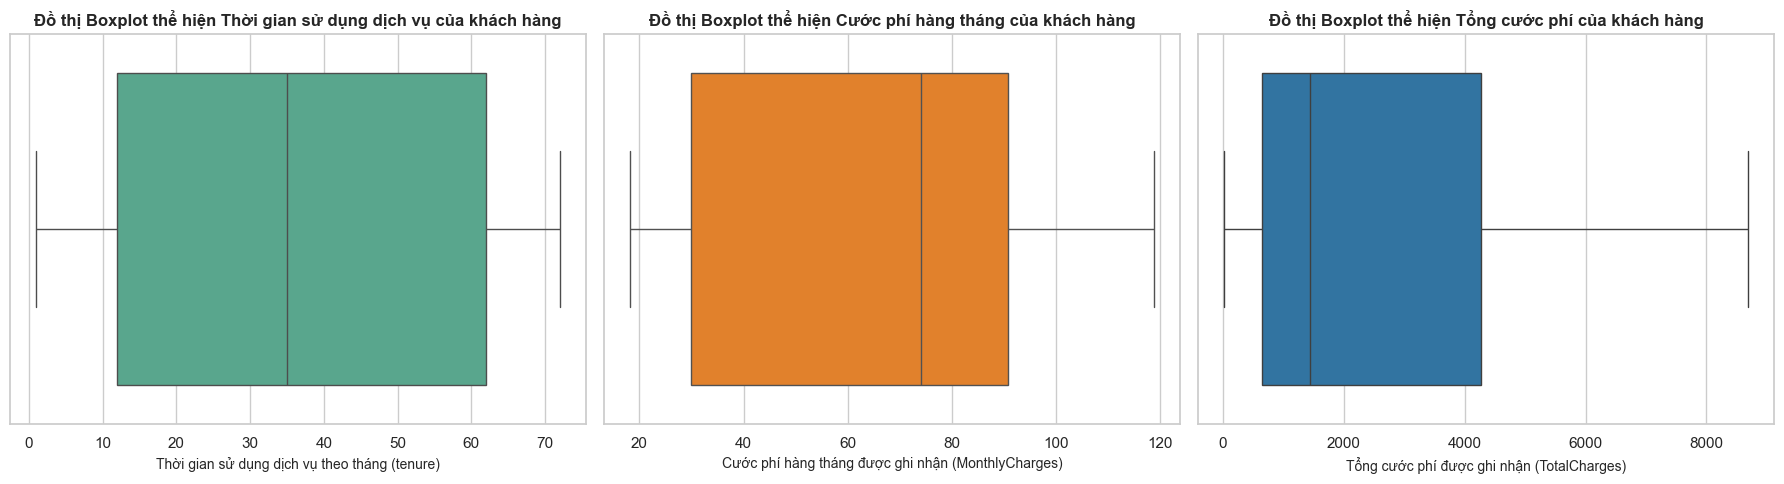

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_train_copy, x='tenure', color='#4CB391', ax=axes[0])
axes[0].set_title(f'Đồ thị Boxplot thể hiện {get_name("tenure")} của khách hàng', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Thời gian sử dụng dịch vụ theo tháng (tenure)', fontsize=10)

sns.boxplot(data=df_train_copy, x='MonthlyCharges', color='#FF7F0E', ax=axes[1])
axes[1].set_title(f'Đồ thị Boxplot thể hiện {get_name("MonthlyCharges")} của khách hàng', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cước phí hàng tháng được ghi nhận (MonthlyCharges)', fontsize=10)

sns.boxplot(data=df_train_copy, x='TotalCharges', color='#1F77B4', ax=axes[2])
axes[2].set_title(f'Đồ thị Boxplot thể hiện {get_name("TotalCharges")} của khách hàng', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tổng cước phí được ghi nhận (TotalCharges)', fontsize=10)

plt.tight_layout()
plt.show()

**Nhận xét:** Quan sát thông qua trực quan hóa cho thấy tất cả quan sát đều nằm trong khoảng không có điểm ngoại lai **Non-outlier region** của ba đặc trưng định lượng `tenure`, `MonthlyCharges`, `TotalCharges`. Có thể thấy rõ điều này hơn thông qua việc xác định khoảng phạm vi dữ liệu hợp lệ **Valid Data Range** và xác định số điểm ngoại lai nằm ngoài khoảng.

In [17]:
def detect_outliers_bounds(columns):
    for col in columns:
        Q1 = df_train_copy[col].quantile(0.25)
        Q3 = df_train_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_count = ((df_train_copy[col] < lower_bound) | (df_train_copy[col] > upper_bound)).sum()

        print(f"Số điểm ngoại lai ứng với đặc trưng {get_name(col)} ({col}): {outliers_count} điểm.")

detect_outliers_bounds(['tenure', 'MonthlyCharges', 'TotalCharges'])

Số điểm ngoại lai ứng với đặc trưng Thời gian sử dụng dịch vụ (tenure): 0 điểm.
Số điểm ngoại lai ứng với đặc trưng Cước phí hàng tháng (MonthlyCharges): 0 điểm.
Số điểm ngoại lai ứng với đặc trưng Tổng cước phí (TotalCharges): 0 điểm.


**Nhận xét:** Thông qua các bước kiểm định chéo, các đặc trưng `tenure`, `MonthlyCharges` và `TotalCharges` không chỉ đảm bảo tính hợp lệ tuyệt đối về mặt toán học và logic nghiệp vụ, mà còn thể hiện phân phối tự nhiên không nằm ngoài khoảng hợp lệ; vì vậy, những kỹ thuật can thiệp dữ liệu như **imputation**, **dropping** hay **capping** được hoàn toàn lược bỏ.

## 3.3. Kiểm tra tính hợp lệ của nhãn các đặc trưng định tính (Categorical Labels Sanity Check)

**Note:** Thực hiện kiểm tra tính đồng nhất nhãn **labels** của các đặc trưng định tính nhằm phát hiện lỗi nhập liệu phổ biến như sai chính tả, bất đồng nhất về cách viết hoặc các danh mục chứa khoảng trắng trước khi thực hiện các kỹ thuật mã hóa **Encoding** cho Machine Learning.

In [18]:
for col in categorical_features:
    unique_labels = df_train_copy[col].unique().tolist()
    print(f" Đặc trưng '{col}': {unique_labels}")

 Đặc trưng 'gender': ['Male', 'Female']
 Đặc trưng 'SeniorCitizen': ['No', 'Yes']
 Đặc trưng 'Partner': ['Yes', 'No']
 Đặc trưng 'Dependents': ['Yes', 'No']
 Đặc trưng 'PhoneService': ['Yes', 'No']
 Đặc trưng 'MultipleLines': ['No', 'Yes', 'No phone service']
 Đặc trưng 'InternetService': ['DSL', 'Fiber optic', 'No']
 Đặc trưng 'OnlineSecurity': ['Yes', 'No', 'No internet service']
 Đặc trưng 'OnlineBackup': ['No', 'Yes', 'No internet service']
 Đặc trưng 'DeviceProtection': ['Yes', 'No', 'No internet service']
 Đặc trưng 'TechSupport': ['Yes', 'No', 'No internet service']
 Đặc trưng 'StreamingTV': ['No', 'Yes', 'No internet service']
 Đặc trưng 'StreamingMovies': ['No', 'Yes', 'No internet service']
 Đặc trưng 'Contract': ['One year', 'Two year', 'Month-to-month']
 Đặc trưng 'PaperlessBilling': ['Yes', 'No']
 Đặc trưng 'PaymentMethod': ['Mailed check', 'Credit card (automatic)', 'Electronic check', 'Bank transfer (automatic)']


**Nhận xét:** Nhãn của các đặc trưng định tính hoàn toàn đồng nhất, không phát hiện các lỗi sai chính tả hay bất đồng nhất chữ hoa chữ thường và phù hợp cho quá trình xử lí tiếp theo.

## 3.4 Kiểm tra tính hợp lệ biến định tính (Categorical Features Sanity Check)

**Note:**  
Thực hiện rà soát tính nhất quán và logic phân lớp của các biến định tính, đặc biệt tập trung vào mối liên hệ hệ thống giữa dịch vụ cốt lõi và các dịch vụ bổ trợ, nhằm triệt tiêu hoàn toàn các mâu thuẫn dữ liệu trước khi tiến hành mã hóa **Encoding**
   - Nhóm dịch vụ Internet: Kiểm tra mâu thuẫn giữa biến `InternetService` và các dịch vụ đi kèm `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, chẳng hạn như các dịch vụ đi kèm lại hiển thị *Yes* trong khi trạng thái lại là *No Internet*.
   - Nhóm dịch vụ Điện thoại: Kiểm tra mâu thuẫn tương tự giữa `PhoneService` và `MultipleLines`.

In [19]:
internet_dependent_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection","TechSupport", "StreamingTV", "StreamingMovies"]
phone_dependent_cols = ["MultipleLines"]

checks = {
        "Sử dụng dịch vụ Internet nhưng không có Internet": int(
            df_train_copy.loc[df_train_copy["InternetService"].eq("No"), internet_dependent_cols]
            .ne("No internet service").any(axis=1).sum()
        ),
        "Sử dụng Internet nhưng không có dịch vụ Internet": int(
            df_train_copy.loc[~df_train_copy["InternetService"].eq("No"), internet_dependent_cols]
            .eq("No internet service").any(axis=1).sum()
        ),
        "Sử dụng dịch vụ điện thoại nhưng không có điện thoại": int(
            df_train_copy.loc[df_train_copy["PhoneService"].eq("No"), phone_dependent_cols]
            .ne("No phone service").any(axis=1).sum()
        ),
         "Sử dụng điện thoại nhưng không có dịch vụ điện thoại": int(
            df_train_copy.loc[df_train_copy["PhoneService"].eq("Yes"), phone_dependent_cols]
            .eq("No phone service").any(axis=1).sum()
        ),
        "Không đăng ký bất kỳ dịch vụ nào": int(
            (df_train_copy["PhoneService"].eq("No") & df_train_copy["InternetService"].eq("No")).sum()
        ),
       
    }
    
print("--- Kiểm tra đặc trưng định tính ---")
display(pd.Series(checks).to_frame("Số lỗi phát hiện tương ứng"))

--- Kiểm tra đặc trưng định tính ---


,Số lỗi phát hiện tương ứng
Sử dụng dịch vụ Internet nhưng không có Internet,0
Sử dụng Internet nhưng không có dịch vụ Internet,0
Sử dụng dịch vụ điện thoại nhưng không có điện thoại,0
Sử dụng điện thoại nhưng không có dịch vụ điện thoại,0
Không đăng ký bất kỳ dịch vụ nào,7


**Note:** Quá trình kiểm tra phát hiện **7** khách hàng có trạng thái sử dụng dịch vụ bất hợp lí khi `PhoneService` = *No* đồng thời `InternetService` = *No*. Việc một tài khoản hoạt động nhưng không sử dụng bất kỳ hạ tầng kết nối cơ bản nào là lỗi dữ liệu nghiêm trọng. Do đó, ta thực hiện loại bỏ **7 quan sát** này nhằm đảm bảo tính logic cho bộ dữ liệu và tránh gây nhiễu mô hình, bắt đầu từ việc liệt kê danh sách khách hàng trong nhóm này.

In [20]:
ghost_customers = df_train_copy[(df_train_copy["PhoneService"] == "No") & (df_train_copy["InternetService"] == "No")]
display(ghost_customers.style.hide(axis='index'))

id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
63922,Female,No,Yes,No,72,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.250000,1466.750000,No
219372,Female,No,Yes,Yes,2,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.950000,24.800000,No
436919,Female,No,Yes,No,72,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.950000,1429.650000,No
445299,Male,No,No,No,1,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,19.100000,19.100000,No
552820,Male,No,Yes,Yes,53,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.700000,1001.500000,No
558760,Female,No,No,No,29,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.650000,672.700000,No
562266,Male,No,Yes,Yes,71,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),35.800000,1573.800000,No


**Note:** Loại bỏ nhóm khách hàng này và kiểm tra thao tác thông qua số lượng dòng trước và sau khi **drop**.

In [21]:
print(f"Số dòng ban đầu: {df_train_copy.shape[0]:,}")
df_train_copy = df_train_copy.drop(ghost_customers.index)
df_train_copy = df_train_copy.reset_index(drop=True)
print(f"Số dòng sau khi làm sạch: {df_train_copy.shape[0]:,}")

Số dòng ban đầu: 594,194
Số dòng sau khi làm sạch: 594,187


**Nhận xét:** Sau khi loại bỏ những điểm bất hợp lí, tập dữ liệu hiện tại đã được đồng bộ logic tuyệt đối. Ngoài ra, sự trùng khớp hoàn hảo giữa các nhóm **No internet service / No phone service** với tình trạng sử dụng dịch vụ là điều kiện lý tưởng để thực hiện mã hóa **One-Hot Encoding**. Việc tạo các siêu cờ **Combo flags** không gặp rủi ro nhiễu hay lệch tín hiệu do mâu thuẫn nội tại của dữ liệu.

# 4. Phân tích Đơn biến: Khảo sát đặc trưng (Univariate Analysis)

## 4.1 Biến định lượng (Numerical Features)

**Note:** Việc thực hiện phân tích đơn biến nhóm đặc trưng định lượng nhằm đánh giá các thông số về độ lệch, phương sai và thông qua trực quan hóa xác định chiến lược chuẩn hóa hoặc biến đổi dữ liệu **Data Transformation** phù hợp trước khi đưa vào huấn luyện.

In [22]:
variance = numerical_data.var()
skewness = numerical_data.skew()
unique_counts = numerical_data.nunique()

summary_table = pd.DataFrame({
    'Variance (Phương sai)': variance,
    'Skewness (Độ lệch)': skewness,
    'Nunique (Số giá trị phân biệt)': unique_counts
}).T

display(summary_table)

,tenure,MonthlyCharges,TotalCharges
Variance (Phương sai),628.10,965.19,"5,540,923.88"
Skewness (Độ lệch),0.06,-0.29,0.91
Nunique (Số giá trị phân biệt),72.00,"1,921.00","31,910.00"


**Nhận xét:**
- `tenture` chỉ thời gian sử dụng dịch vụ tính theo tháng nên chỉ phân bố trong khoảng nhỏ xác định. `MonthlyCharges`, `TotalCharges` là cước phí theo tháng và tổng cước phí của khách hàng nên phân bố rất rộng, nhưng nhìn chung dữ liệu định lượng gốc ít bị lệch. Điều này có thể được quan sát thông qua đồ thị Histogram của dữ liệu theo từng đặc trưng.

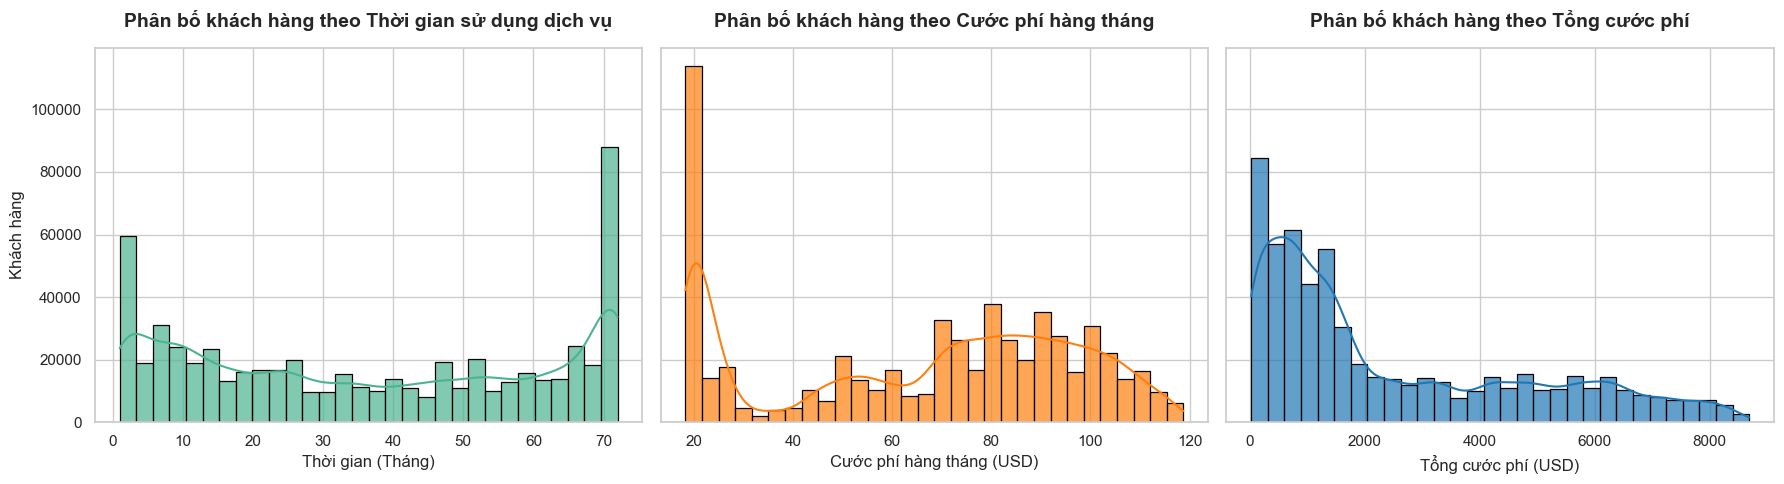

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5),sharey=True)
colors = ['#4CB391', '#FF7F0E', '#1F77B4'] 

for i, col in enumerate(numerical_features):
    sns.histplot(
    data=df_train_copy, 
    x=col, 
    ax=axes[i], 
    bins=30, 
    kde=True, 
    color=colors[i], 
    edgecolor='black', 
    alpha=0.7,
    kde_kws={'cut': 0, 'bw_adjust': 1.5} 
)
    
    axes[i].set_title(f'Phân bố khách hàng theo {get_name(col)}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_ylabel('Khách hàng' if i == 0 else '', fontsize=12)
axes[0].set_xlabel('Thời gian (Tháng)', fontsize=12)
axes[1].set_xlabel('Cước phí hàng tháng (USD)',fontsize=12)
axes[2].set_xlabel('Tổng cước phí (USD)',fontsize=12)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Phân bố thời gian gắn bó `tenure` có dạng phân phối hai đỉnh **Bimodal Distribution**. Khách hàng tập trung với mật độ rất cao ở hai biên, bao gồm nhóm khách hàng mới với thời gian sử dụng dịch vụ dưới **6** tháng và nhóm khách hàng lâu năm với thời gian sử dụng dịch vụ từ **60** tháng trở lên. Giữa hai đỉnh này phân bố khá đồng đều.
- Cước phí hàng tháng `MonthlyCharges` ghi nhận một đỉnh mang giá trị rất cao ở mức phí thấp nhất, cho thấy phần lớn khách hàng chỉ sử dụng gói dịch vụ cơ bản nhất. Phần còn lại còn lại trải dài từ **40$** đến **115$** với các đỉnh nhỏ nhấp nhô nhưng không có mức cước nào quá áp đảo.
- Tổng cước phí `TotalCharges` lệch phải mạnh **Right-skewed**. Đa số khách hàng có tổng mức chi tiêu tích lũy thấp, tập trung dày đặc ở vùng từ **0-2,000$**, giảm dần với phần đuôi kéo dài đến hơn **8,000$**. Điều này hoàn toàn hợp lý khi nhóm khách hàng mới và nhóm dùng gói cước cơ bản chiếm tỷ trọng lớn, trực tiếp kéo tổng cước phí tích lũy của họ xuống mức thấp.

**Kết luận:** 
- Dựa trên hình dạng phân phối, `tenure` có thể được chia theo khoảng thời gian gắn bó: *Khách hàng mới từ 1 - 6 tháng*, *Khách hàng tiêu chuẩn từ 7 - 48 tháng, và *Khách hàng lâu năm, gắn bó trên 48 tháng*. Vì các nhóm mang tính thứ bậc, phương pháp Mã hóa thứ tự **Ordinal Encoding** nên được ưu tiên để giữ lại đặc trưng này.
- Các đặc trưng định lượng gốc có sự chênh lệch lớn về biên độ với `MonthlyCharges` ở mức hàng chục và `MonthlyCharges`, `TotalCharges` lên đến hàng nghìn đặt ra yêu cầu áp dụng các kỹ thuật chuẩn hóa như **Min-Max Scaler** hoặc **Standard Scaler**, tránh sai lệch trọng số cho các mô hình nhạy cảm với khoảng cách như **KNN** hay **SVM**.
- `TotalCharges` có phân bố lệch phải mạnh **Right-skewed**, dù vậy đồ thị Boxplot cho thấy dữ liệu không xuất hiện các giá trị ngoại lai bất thường. Có thể cân nhắc sử dụng kỹ thuật Biến đổi Logarit **Log Transformation** hoặc thực hiện Rời rạc hóa **Binning** thành các nhóm khoảng chi tiêu để đưa các đặc trưng này vào các mô hình tuyến tính như Logistic Regression, nhằm làm mượt dữ liệu một cách hiệu quả.

## 4.2 Biến định tính (Categorical Features)

**Note:**  
Khảo sát thông qua trực quan hóa các đặc trưng định tính nhằm xác định không gian mẫu và cấu trúc phân bố của từng thuộc tính, qua đó phát hiện sự mất cân bằng dữ liệu, góp phần xây dựng chiến lược mã hóa **Encoding** và chuẩn bị dữ liệu phù hợp cho mô hình.

**Note:** Đổi tên đặc trưng để phục vụ cho mục đích hiển thị.

In [24]:
config_features = {
    'gender': {'name': 'Giới tính', 'order': ['Male', 'Female']},
    'SeniorCitizen': {'name': 'Tiêu chí người cao tuổi', 'order': ['Yes', 'No']},
    'Partner': {'name': 'Tiêu chí bạn đời', 'order': ['Yes', 'No']},
    'Dependents': {'name': 'Tiêu chí người chăm sóc', 'order': ['Yes', 'No']},
    'PhoneService': {'name': 'Dịch vụ điện thoại', 'order': ['Yes', 'No']},
    'PaperlessBilling': {'name': 'Dịch vụ hóa đơn điện tử', 'order': ['Yes', 'No']},
    'MultipleLines': {'name': 'Dịch vụ đa tuyến', 'order': ['Yes', 'No', 'No phone service']},
    'OnlineSecurity': {'name': 'Dịch vụ bảo mật trực tuyến', 'order': ['Yes', 'No', 'No internet service']},
    'OnlineBackup': {'name': 'Dịch vụ sao lưu trực tuyến', 'order': ['Yes', 'No', 'No internet service']},
    'DeviceProtection': {'name': 'Dịch vụ bảo hiểm thiết bị', 'order': ['Yes', 'No', 'No internet service']},
    'TechSupport': {'name': 'Dịch vụ hỗ trợ kỹ thuật', 'order': ['Yes', 'No', 'No internet service']},
    'StreamingTV': {'name': 'Dịch vụ truyền hình trực tuyến', 'order': ['Yes', 'No', 'No internet service']},
    'StreamingMovies': {'name': 'Dịch vụ xem phim trực tuyến', 'order': ['Yes', 'No', 'No internet service']},

    'InternetService': {'name': 'Loại dịch vụ Internet', 'order': None},
    'Contract': {'name': 'Loại hợp đồng', 'order': None},
    'PaymentMethod': {'name': 'Phương thức thanh toán', 'order': None}
}

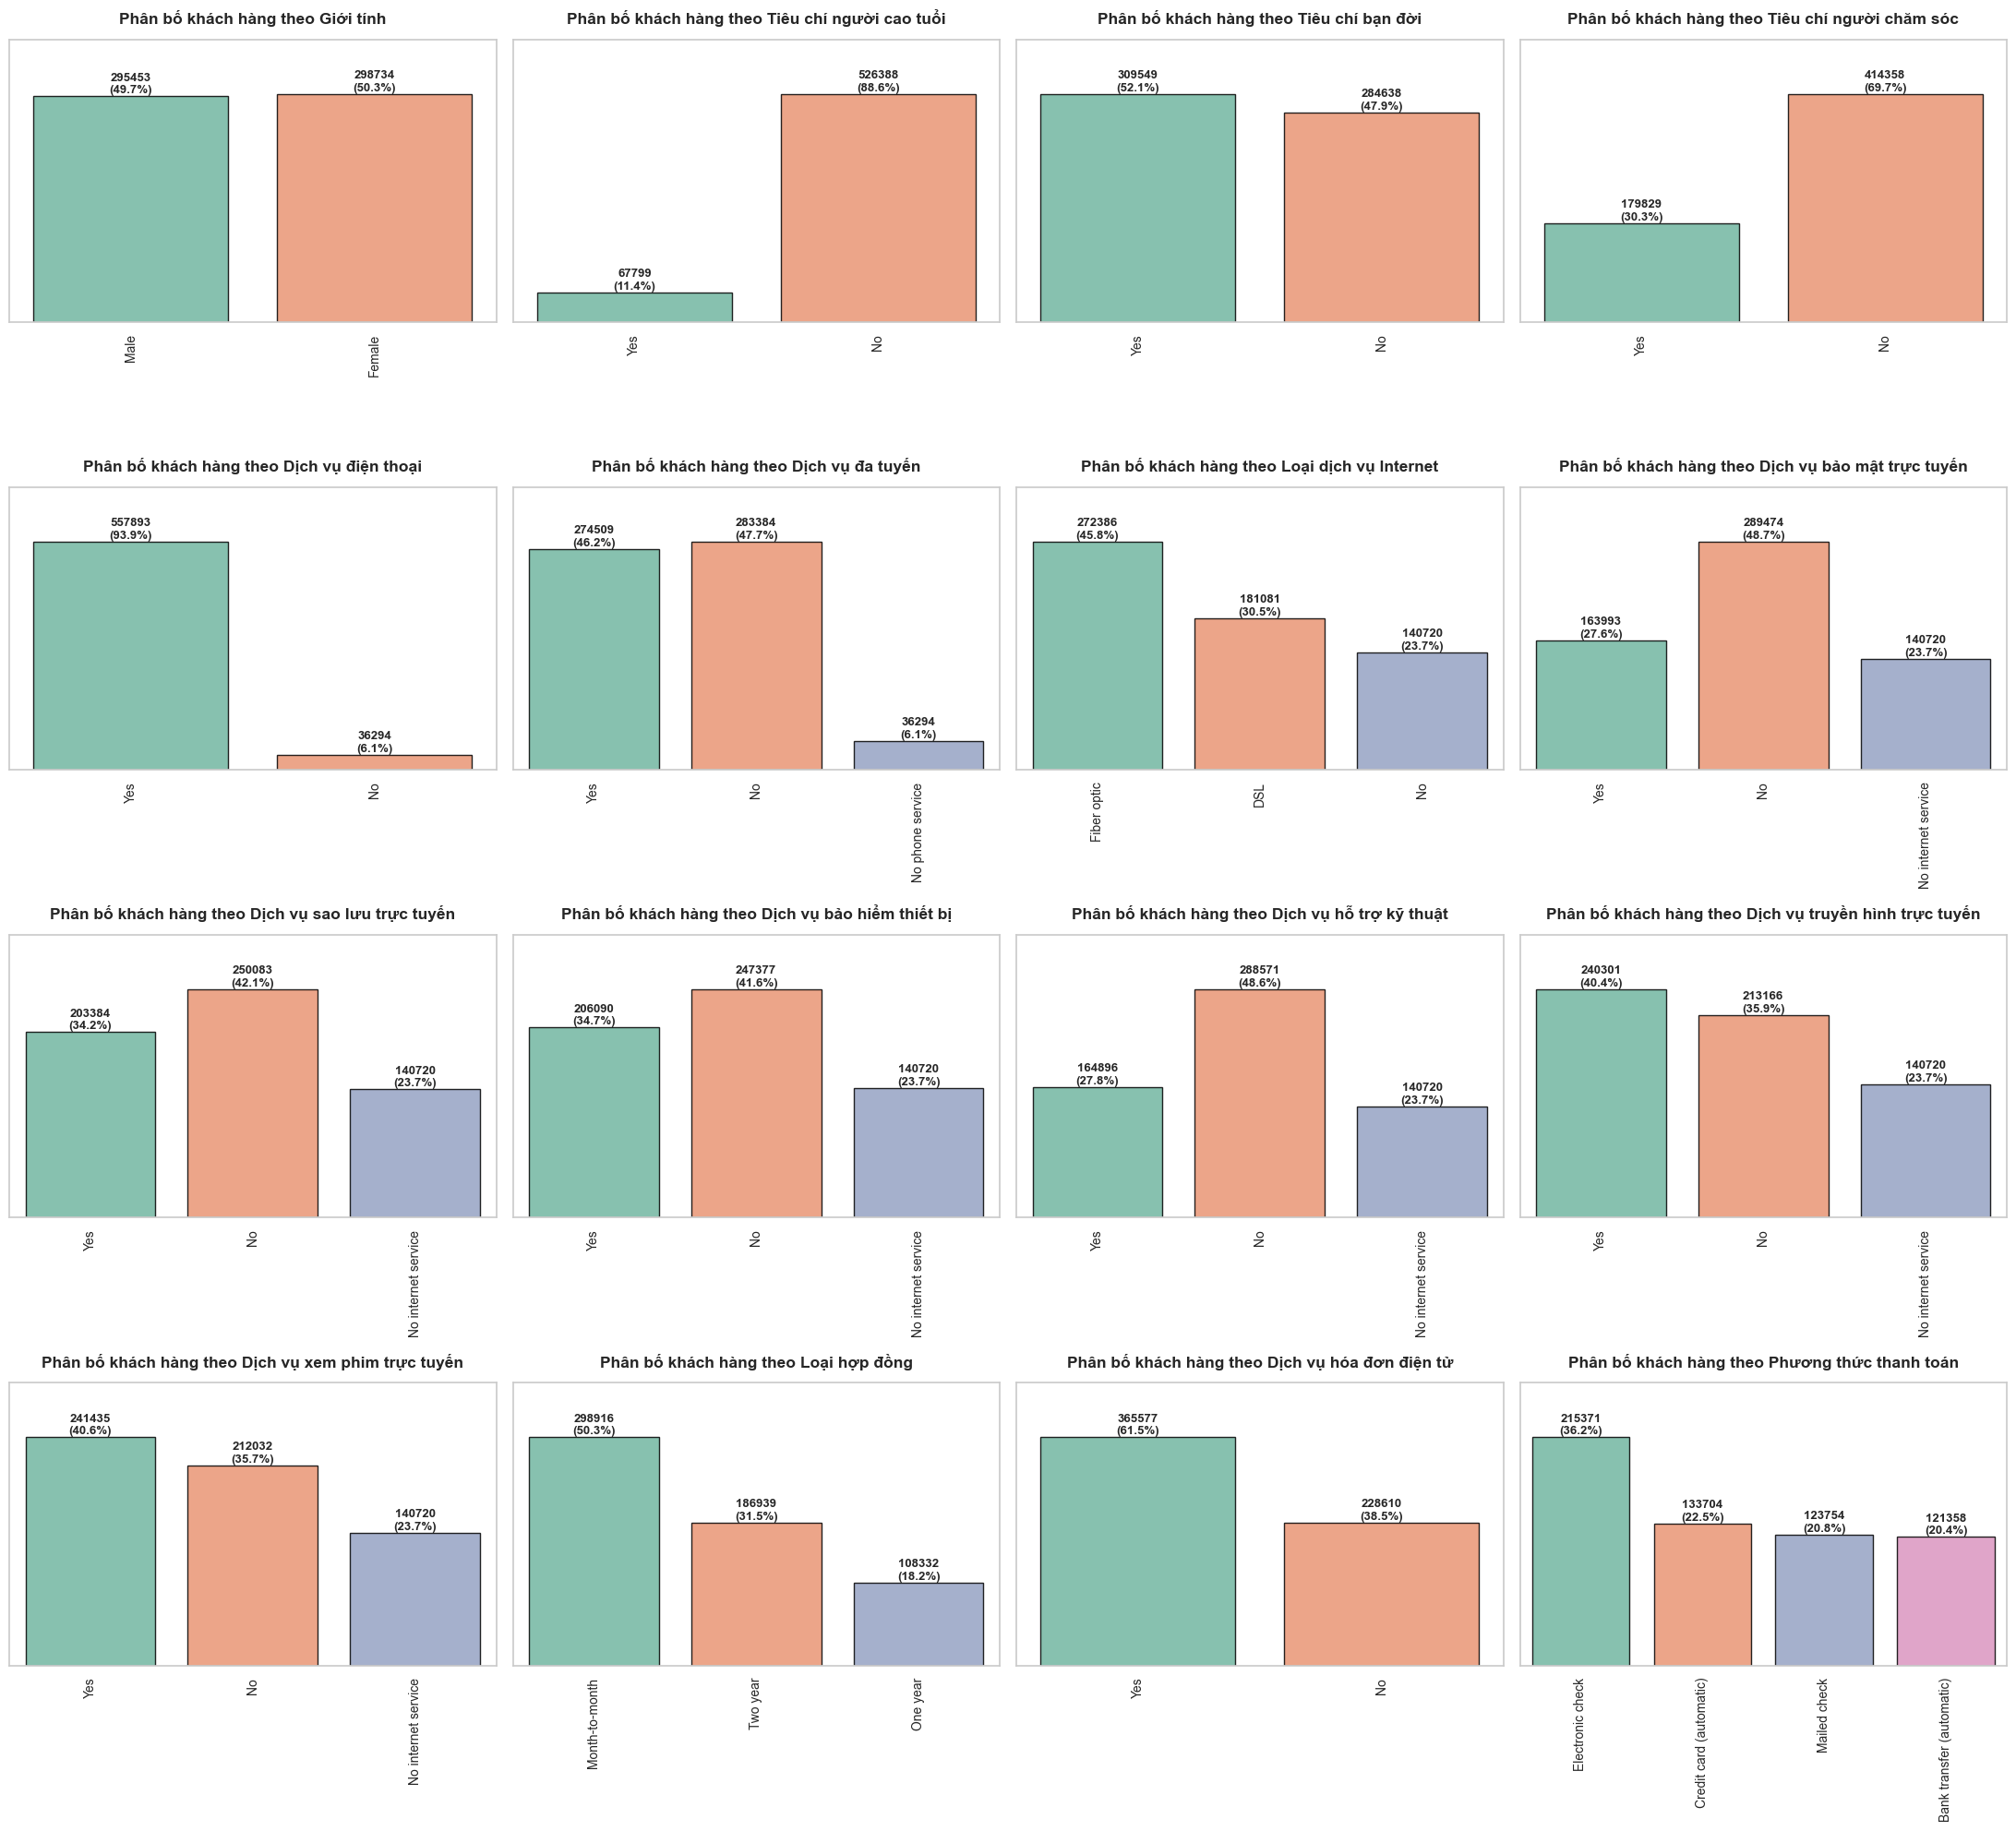

In [25]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(22, 20))
axes = axes.flatten()

custom_palette = sns.color_palette('Set2', 4)

for i, col in enumerate(categorical_features):
    if col not in config_features:
        continue
        
    feature_info = config_features[col]
    ten = feature_info['name']


    if feature_info['order'] is not None:
        category_order = feature_info['order']
    else:
        category_order = df_train_copy[col].value_counts().index.tolist()
    
    color_mapping = {label: custom_palette[idx] for idx, label in enumerate(category_order)}
    
    sns.countplot(
        data=df_train_copy, 
        x=col, 
        order=category_order,
        hue_order=category_order,
        hue=col,
        ax=axes[i], 
        palette=color_mapping,
        edgecolor='black',
        alpha=0.85,
        legend=False
    )

    total = len(df_train_copy[col])
    for p in axes[i].patches:
        height = p.get_height()
        pct = height / total * 100
        y_position = height + (total * 0.01)
        axes[i].annotate(
            f'{int(height)}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9.5, fontweight='bold'
        )
    
    ymax = axes[i].get_ylim()[1]
    axes[i].set_ylim(0, ymax * 1.18)
    
    axes[i].set_title(f'Phân bố khách hàng theo {ten}', fontsize=12.5, fontweight='bold', pad=12)
    
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_yticks([])
    axes[i].set_yticklabels([])
    

    axes[i].tick_params(axis='x', rotation=90, labelsize=10)

plt.tight_layout()
plt.show()

In [26]:
rows = []
for i, col in enumerate(categorical_features, start=1):
    counts = df_train_copy[col].value_counts(dropna=False)
    ten_tieng_viet = config_features[col]['name']
    rows.append({
        "STT": i,
        "Đặc trưng gốc (Feature)": col,
        "Ý nghĩa đặc trưng":ten_tieng_viet,
        "Số giá trị phân biệt": df_train_copy[col].nunique(dropna=False),
        "Giá trị áp đảo": counts.index[0],
        "Tỷ lệ tương ứng": counts.iloc[0] / len(df_train_copy) * 100,
        "Số giá trị hiếm (< 1%)": int((counts / len(df_train_copy) < 0.01).sum()),
    })

cat_summary = pd.DataFrame(rows)

display(cat_summary.style.format({'Tỷ lệ tương ứng': '{:.2f}%'}).hide(axis="index"))

STT,Đặc trưng gốc (Feature),Ý nghĩa đặc trưng,Số giá trị phân biệt,Giá trị áp đảo,Tỷ lệ tương ứng,Số giá trị hiếm (< 1%)
1,gender,Giới tính,2,Female,50.28%,0
2,SeniorCitizen,Tiêu chí người cao tuổi,2,No,88.59%,0
3,Partner,Tiêu chí bạn đời,2,Yes,52.10%,0
4,Dependents,Tiêu chí người chăm sóc,2,No,69.74%,0
5,PhoneService,Dịch vụ điện thoại,2,Yes,93.89%,0
6,MultipleLines,Dịch vụ đa tuyến,3,No,47.69%,0
7,InternetService,Loại dịch vụ Internet,3,Fiber optic,45.84%,0
8,OnlineSecurity,Dịch vụ bảo mật trực tuyến,3,No,48.72%,0
9,OnlineBackup,Dịch vụ sao lưu trực tuyến,3,No,42.09%,0
10,DeviceProtection,Dịch vụ bảo hiểm thiết bị,3,No,41.63%,0


**Nhận xét:**
- Tập dữ liệu có tính phân nhánh khá đồng đều. Phần lớn đặc trưng chỉ xoay quanh **2** đến **3** nhãn phân biệt, đặc trưng có độ phức tạp cao nhất `PaymentMethod` cũng chỉ mang **4** giá trị phân biệt.
- Không xuất hiện tình trạng nhãn hiếm **Rare Labels**. Tất cả các nhóm giá trị trong từng đặc trưng đều chiếm tỷ trọng đáng kể với mức thấp nhất **6.1%** của `PhoneService` và `MultipleLines`.
- `PhoneService` có sự phân hóa thấp nhất khi nhãn *Yes* chiếm ưu thế tuyệt đối lên tới **93.89%**, theo đó lượng khách hàng không sử dụng dịch vụ gọi điện chỉ chiếm **6.1%**.
- Các dịch vụ hỗ trợ như `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` và dịch vụ cơ bản `InternetService` đều có nhóm khách hàng không đăng ký internet *No internet service* chiếm tỷ lệ cố định **23.7%**. Điều tương tự với `MultipleLines` và dịch vụ `PhoneService` khi nhóm khách hàng không đăng kí dịch vụ điện thoại chiếm **6.1%** tổng số khách hàng. Nhờ đó, ta có thể thực hiện phân nhóm các đặc trưng này để tìm ra vùng rủi ro rời bỏ dịch vụ của khách hàng.

**Kết luận:**
- Vì toàn bộ các đặc trưng đều có độ phân nhánh thấp, phương pháp **One-Hot Encoding** được áp dụng đồng loạt để số hóa dữ liệu. Cấu trúc này đảm bảo mô hình hiểu đúng ý nghĩa nhãn phân loại mà không gặp rủi ro bùng nổ chiều dữ liệu **Curse of Dimensionality**.
- Nhóm khách hàng *No internet service* chiếm tỷ lệ **23.7%** với tất cả các dịch vụ hỗ trợ dịch vụ mạng và *No phone service* với **6.1%** tổng số khách hàng được giữ nguyên thay vì gộp nhãn với nhóm *No* nhằm phục vụ phân tích **Risk Gap** và phân tích sức giữ chân khách hàng.
- `PhoneService` có độ phân hóa rất thấp khi **93.89%** mẫu dữ liệu rơi vào nhóm *Yes*. Sự mất cân bằng này khiến đặc trưng mang tính nhiễu cao và không đóng góp đáng kể vào khả năng dự báo của mô hình.

## 4.3 Phân bố biến mục tiêu (Target Variable - `Churn`)

**Note:** Thực hiện trực quan hóa hành vi khách hàng nhằm đánh giá tỷ lệ khách hàng tiếp tục sử dụng dịch vụ so với nhóm rời bỏ, xác định mức độ mất cân bằng dữ liệu **Imbalanced Data**, qua đó xác định phương pháp phân tách tập mẫu và lựa chọn thước đo đánh giá mô hình **Evaluation Metric** phù hợp.

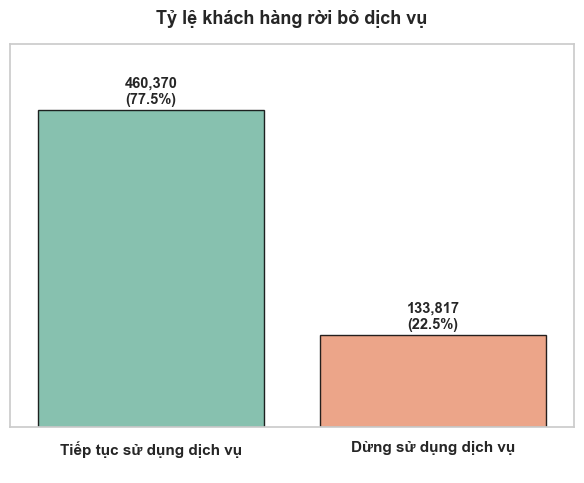

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
churn_counts = df_train_copy['Churn'].value_counts()
total = len(df_train_copy)

labels_vn = {'No': 'Tiếp tục sử dụng dịch vụ\n', 'Yes': 'Dừng sử dụng dịch vụ\n'}
category_order = ['No', 'Yes']

custom_palette = sns.color_palette('Set2', 2)
color_mapping = {label: custom_palette[idx] for idx, label in enumerate(category_order)}

sns.countplot(
    data=df_train_copy,
    x='Churn',
    order=category_order,
    hue_order=category_order,
    hue='Churn',
    ax=ax,
    palette=color_mapping,
    edgecolor='black',
    alpha=0.85,
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    pct = height / total * 100
    y_position = height + (total * 0.01)
    ax.annotate(
            f'{int(height):,}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2., y_position),
            ha='center', va='bottom',
            fontsize=10.5, fontweight='bold'
        )

ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * 1.15)

ax.set_title('Tỷ lệ khách hàng rời bỏ dịch vụ', fontsize=13, fontweight='bold', pad=15)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_xticks(range(len(category_order)))
ax.set_xticklabels([labels_vn[label] for label in category_order], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:** Tập dữ liệu thể hiện sự mất cân bằng mẫu ở mức độ vừa phải với tỷ lệ xấp xỉ **3.5 : 1**, với nhóm khách hàng tiếp tục sử dụng dịch vụ chiếm **77.5%**. Nhóm khách hàng rời bỏ dịch vụ — nhóm mục tiêu cốt lõi cần dự đoán — chiếm phần thiểu số với **22.5%** trên tổng số khách hàng.

**Kết luận:**
- Áp dụng kỹ thuật phân tầng **Stratified Sampling** như **Stratified K-Fold** hoặc **Stratified Shuffle Split** trong quá trình chia tập Train/Validation/Test nhằm đảm bảo tính nguyên vẹn của tỷ lệ cấu trúc **22.5%** rời bỏ dịch vụ trên mọi nếp gấp **fold**, tránh hiện tượng sai lệch phân phối giữa các tập dữ liệu.
- Loại bỏ thước đo **Accuracy** để tránh bẫy tối ưu sai lệch, thay thế bởi **F1-Score** và **Precision-Recall AUC** nhằm đánh giá trực tiếp khả năng nhận diện nhóm khách hàng rời bỏ dịch vụ, kết hợp với **ROC-AUC** để đánh giá năng lực phân tách rủi ro tổng thể của mô hình.
- Có thể ngăn chặn thiên lệch **bias** về phía nhóm đa số bằng cách kích hoạt các tham số phạt thực thể thuộc nhóm thiểu số trong hàm mất mát, chẳng hạn như cấu hình **scale_pos_weight** trong **XGBoost** hoặc **class_weight='balanced'** trong **Random Forest/Logistic Regression**.

# 5. Phân tích Song biến: Động cơ rời bỏ (Bivariate Analysis)

## 5.1 Phân tích nhóm biến định lượng (Numerical Features vs Target)

**Note:** Gán nhãn cho `Churn`, sử dụng cho mục đích hiển thị

In [28]:
churn_labels = {"No": "Tiếp tục sử dụng", "Yes": "Dừng sử dụng"}

**Note:** Trực quan hóa phân phối của `Churn` theo các đặc trưng định lượng gốc bằng các đồ thị phân phối Histplot/KDE và biểu đồ hộp Boxplot nhằm đánh giá hình dạng phân phối và sự dịch chuyển trọng tâm dữ liệu giữa *Nhóm khách hàng tiếp tục sử dụng Dịch vụ* và *Nhóm khách hàng dừng sử dụng dịch vụ*, qua đó phát hiện các điểm gãy phân phối, các ngưỡng giá trị tới hạn để làm cơ sở vững chắc cho các quyết định **Feature Engineering** như phân nhóm, tạo cờ cảnh báo hoặc biến đổi tỷ lệ ở bước tiếp theo.

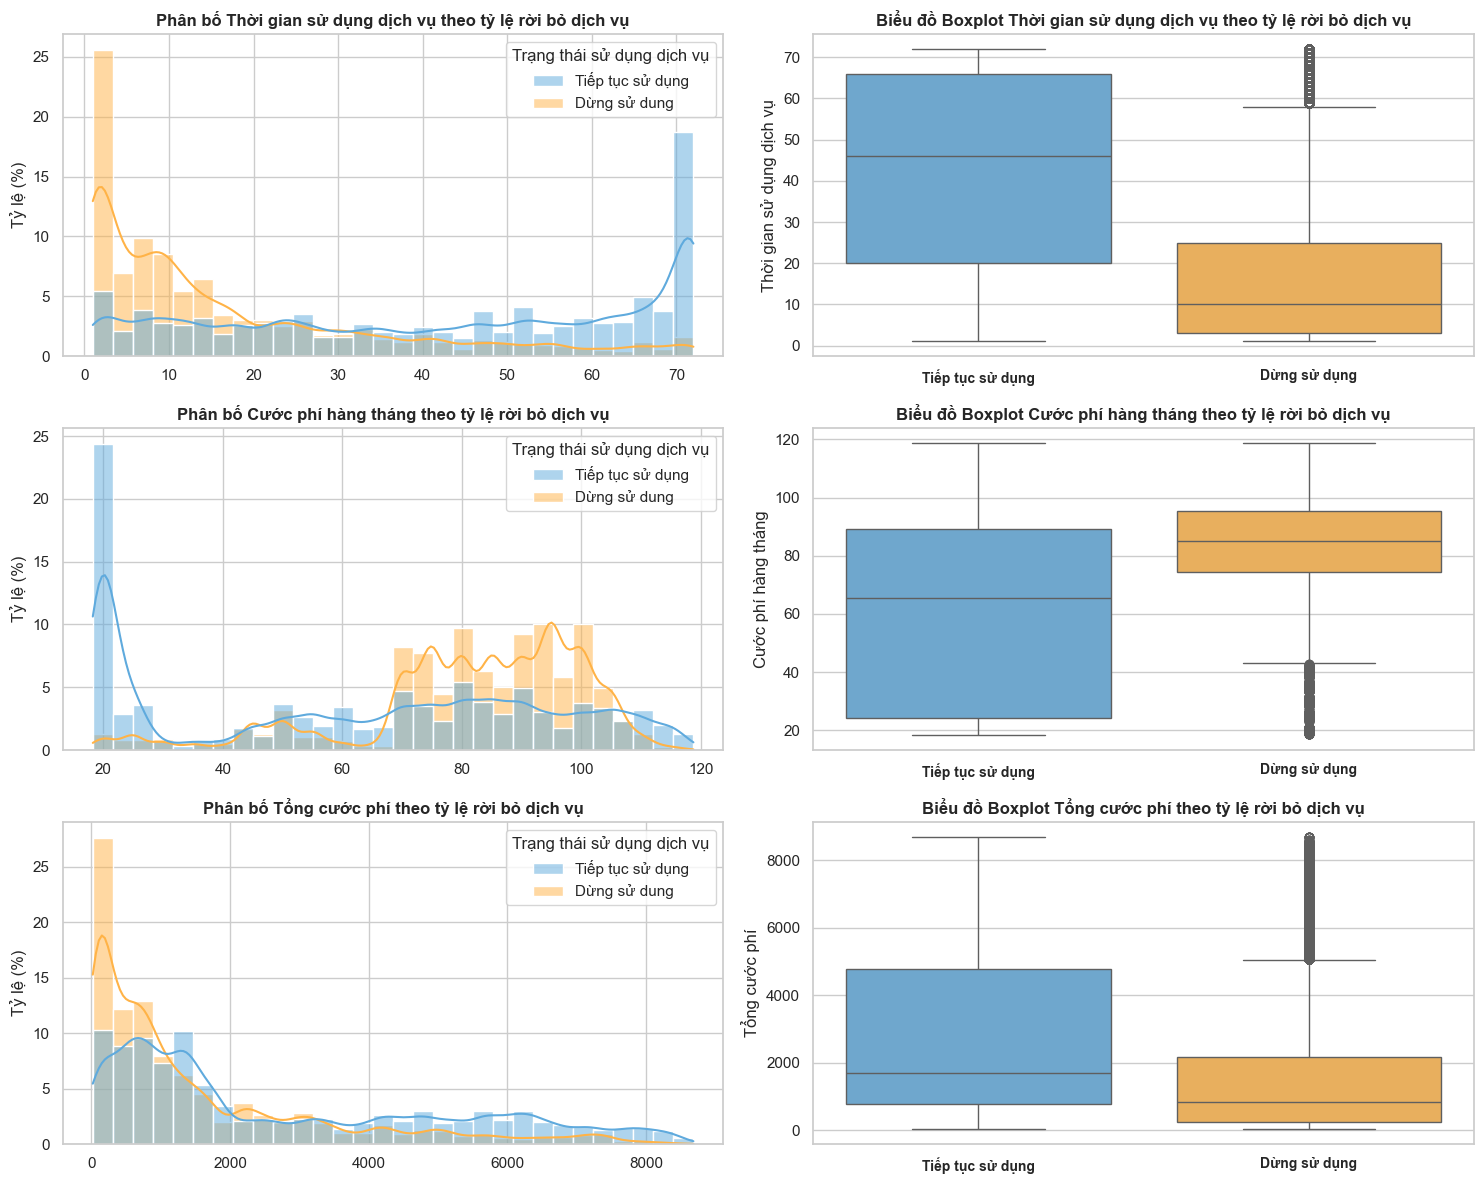

In [29]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(15, 4 * len(numerical_features)))

churn_palette = {"Yes": "#FFB347", "No": "#5FAADD"} 

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df_train_copy, 
        x=col, 
        hue="Churn",
        hue_order=["No", "Yes"], 
        kde=True, 
        bins=30,
        stat="percent", 
        common_norm=False,
        palette=churn_palette,
        ax=axes[i, 0],
        legend = True
    )
    axes[i, 0].set_title(f"Phân bố {get_name(col)} theo tỷ lệ rời bỏ dịch vụ", fontsize=12, fontweight='bold')
    axes[i, 0].set_ylabel("Tỷ lệ (%)")
    axes[i, 0].set_xlabel("")

    if axes[i, 0].get_legend():
        axes[i, 0].get_legend().set_title("Trạng thái sử dụng dịch vụ")
        for text, label in zip(axes[i, 0].get_legend().get_texts(), ['Tiếp tục sử dụng', 'Dừng sử dung']):
            text.set_text(label)

    sns.boxplot(
        data=df_train_copy, 
        x="Churn", 
        y=col, 
        hue="Churn",
        order=["No","Yes"],
        legend=False,
        palette=churn_palette,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Biểu đồ Boxplot {get_name(col)} theo tỷ lệ rời bỏ dịch vụ", fontsize=12, fontweight='bold')
    
    axes[i, 1].set_ylabel(get_name(col))
    axes[i, 1].set_xlabel('')

    axes[i, 1].set_xticks([0,1])
    axes[i, 1].set_xticklabels([churn_labels["No"], churn_labels["Yes"]], fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:** 
- Thời gian gắn bó `tenure` xuất hiện sự phân tách rõ rệt về hành vi. Nhóm dừng sử dụng dịch vụ tập trung chủ yếu ở giai đoạn trải nghiệm dịch vụ từ **1** đến **6** tháng đầu tiên. Ngược lại, nhóm tiếp tục sử dụng dịch vụ chiếm ưu thế ở các thời gian trên **48** tháng. Trung vị thời gian gắn bó của nhóm rời đi là khoảng **10** tháng.
- Phân bố cước phí hàng tháng `MonthlyCharges` chứng minh khách hàng cực kỳ nhạy cảm về giá khi nhóm tiếp tục sử dụng dịch vụ tập tủng với mật độ rất cao ở mốc **20$**. Ngược lại, nhóm rời bỏ phần lớn tập trung ở phân khúc cước phí cao từ **70$** đến **105$**. Đồ thị Boxplot khẳng định nhóm dừng sử dụng dịch vụ có trung vị mức cước phí theo tháng cao hơn hẳn so với nhóm còn lại.
- Trực quan hóa tổng chi phí `TotalCharges` cho thấy cả hai nhóm đều có phân phối lệch phải **Right-Skewed**. Dù vậy, nhóm rời bỏ dịch vụ chiếm phần áp đảo ở mức quanh mốc $0$. Điều này hoàn toàn hợp lí vì phần lớn trong số họ hủy dịch vụ ngay từ những tháng đầu tiên, dẫn đến tổng chi phí tích lũy ở mức thấp.

## 5.2 Phân tích nhóm biến định tính (Categorical Features vs Target)

**Note:** Việc phân tích song biến **Bivariate Analysis** nhóm đặc trưng định tính *Categorical Features* và biến mục tiêu `Churn` nhằm đánh giá sự phân hóa tỷ lệ dừng sử dụng dịch vụ giữa các hạng mục khác nhau như loại hợp đồng, phương thức thanh toán,... qua đó xác định các phân khúc khách hàng mang rủi ro cao nhất. Ngoài ra, dựa trên các mẫu hành vi tiêu dùng để thực hiện tinh chỉnh không gian mẫu **Category Grouping**, lựa chọn chiến lược mã hóa **Encoding** tối ưu.

**Note:** Gán cờ nhị phân *binary flag* cho biến **Churn**

In [30]:
df_train_copy = df_train_copy.assign(churn_flag=df_train_copy["Churn"].eq("Yes").astype(int))

**Note:** Thiết lập bảng tính Mức độ phân hóa rủi ro **Risk Spread** cho nhóm biến định tính nhằm đánh giá mức độ phân hóa rủi ro **Churn Spread** giữa hai nhãn mang rủi ro cao nhất và thấp nhất trong cùng một đặc trưng, sau đó sắp xếp và sàng lọc những biến định tính có sự phân hóa lớn nhất, mang ý nghĩa dự đoán tốt nhất.

In [31]:
rows = []
total_length = len(df_train_copy)

for col in categorical_features:
    grouped = df_train_copy.groupby(col, dropna=False)["churn_flag"].agg(churn_rate="mean", rows="size")

    high = grouped.sort_values("churn_rate", ascending=False).iloc[0]
    low = grouped.sort_values("churn_rate", ascending=True).iloc[0]
    
    ten_tieng_viet = config_features[col]['name']
    
    rows.append({
        "Đặc trưng": col,
        "Ý nghĩa đặc trưng": ten_tieng_viet,
        "Số giá trị phân biệt": df_train_copy[col].nunique(),
        "Giá trị mang rủi ro cao nhất": high.name,
        "Quy mô tệp khách hàng rủi ro cao nhất": (int(high["rows"]) / total_length) * 100,
        "Tỷ lệ rời bỏ nhóm rủi ro cao nhất": high["churn_rate"] * 100,
        
        "Giá trị mang rủi ro thấp nhất": low.name,
        "Quy mô tệp khách hàng rủi ro thấp nhất": (int(low["rows"]) / total_length) * 100,
        "Tỷ lệ rời bỏ nhóm rủi ro thấp nhất": low["churn_rate"] * 100,
        
        "Mức độ phân hóa rủi ro": (high["churn_rate"] - low["churn_rate"]) * 100,
    })

risk_spread = pd.DataFrame(rows)
risk_spread = risk_spread.sort_values("Mức độ phân hóa rủi ro", ascending=False)

display(
     risk_spread.style.format({
        'Quy mô tệp khách hàng rủi ro cao nhất': '{:.2f}%', 
        'Quy mô tệp khách hàng rủi ro thấp nhất': '{:.2f}%', 
        'Mức độ phân hóa rủi ro': '{:.2f}%',
        'Tỷ lệ rời bỏ nhóm rủi ro cao nhất': '{:.2f}%',
        'Tỷ lệ rời bỏ nhóm rủi ro thấp nhất': '{:.2f}%'
    }).hide(axis="index"))

Đặc trưng,Ý nghĩa đặc trưng,Số giá trị phân biệt,Giá trị mang rủi ro cao nhất,Quy mô tệp khách hàng rủi ro cao nhất,Tỷ lệ rời bỏ nhóm rủi ro cao nhất,Giá trị mang rủi ro thấp nhất,Quy mô tệp khách hàng rủi ro thấp nhất,Tỷ lệ rời bỏ nhóm rủi ro thấp nhất,Mức độ phân hóa rủi ro
PaymentMethod,Phương thức thanh toán,4,Electronic check,36.25%,48.91%,Credit card (automatic),22.50%,6.93%,41.97%
Contract,Loại hợp đồng,3,Month-to-month,50.31%,42.05%,Two year,31.46%,1.00%,41.06%
InternetService,Loại dịch vụ Internet,3,Fiber optic,45.84%,41.54%,No,23.68%,1.43%,40.11%
OnlineSecurity,Dịch vụ bảo mật trực tuyến,3,No,48.72%,40.61%,No internet service,23.68%,1.43%,39.18%
TechSupport,Dịch vụ hỗ trợ kỹ thuật,3,No,48.57%,40.16%,No internet service,23.68%,1.43%,38.73%
OnlineBackup,Dịch vụ sao lưu trực tuyến,3,No,42.09%,39.10%,No internet service,23.68%,1.43%,37.67%
DeviceProtection,Dịch vụ bảo hiểm thiết bị,3,No,41.63%,38.06%,No internet service,23.68%,1.43%,36.63%
SeniorCitizen,Tiêu chí người cao tuổi,2,Yes,11.41%,50.03%,No,88.59%,18.98%,31.05%
StreamingMovies,Dịch vụ xem phim trực tuyến,3,No,35.68%,29.93%,No internet service,23.68%,1.43%,28.50%
StreamingTV,Dịch vụ truyền hình trực tuyến,3,No,35.88%,29.74%,No internet service,23.68%,1.43%,28.31%


**Note:** Trực quan hóa các đặc trưng có mức phân hóa rủi ro cao nhất.

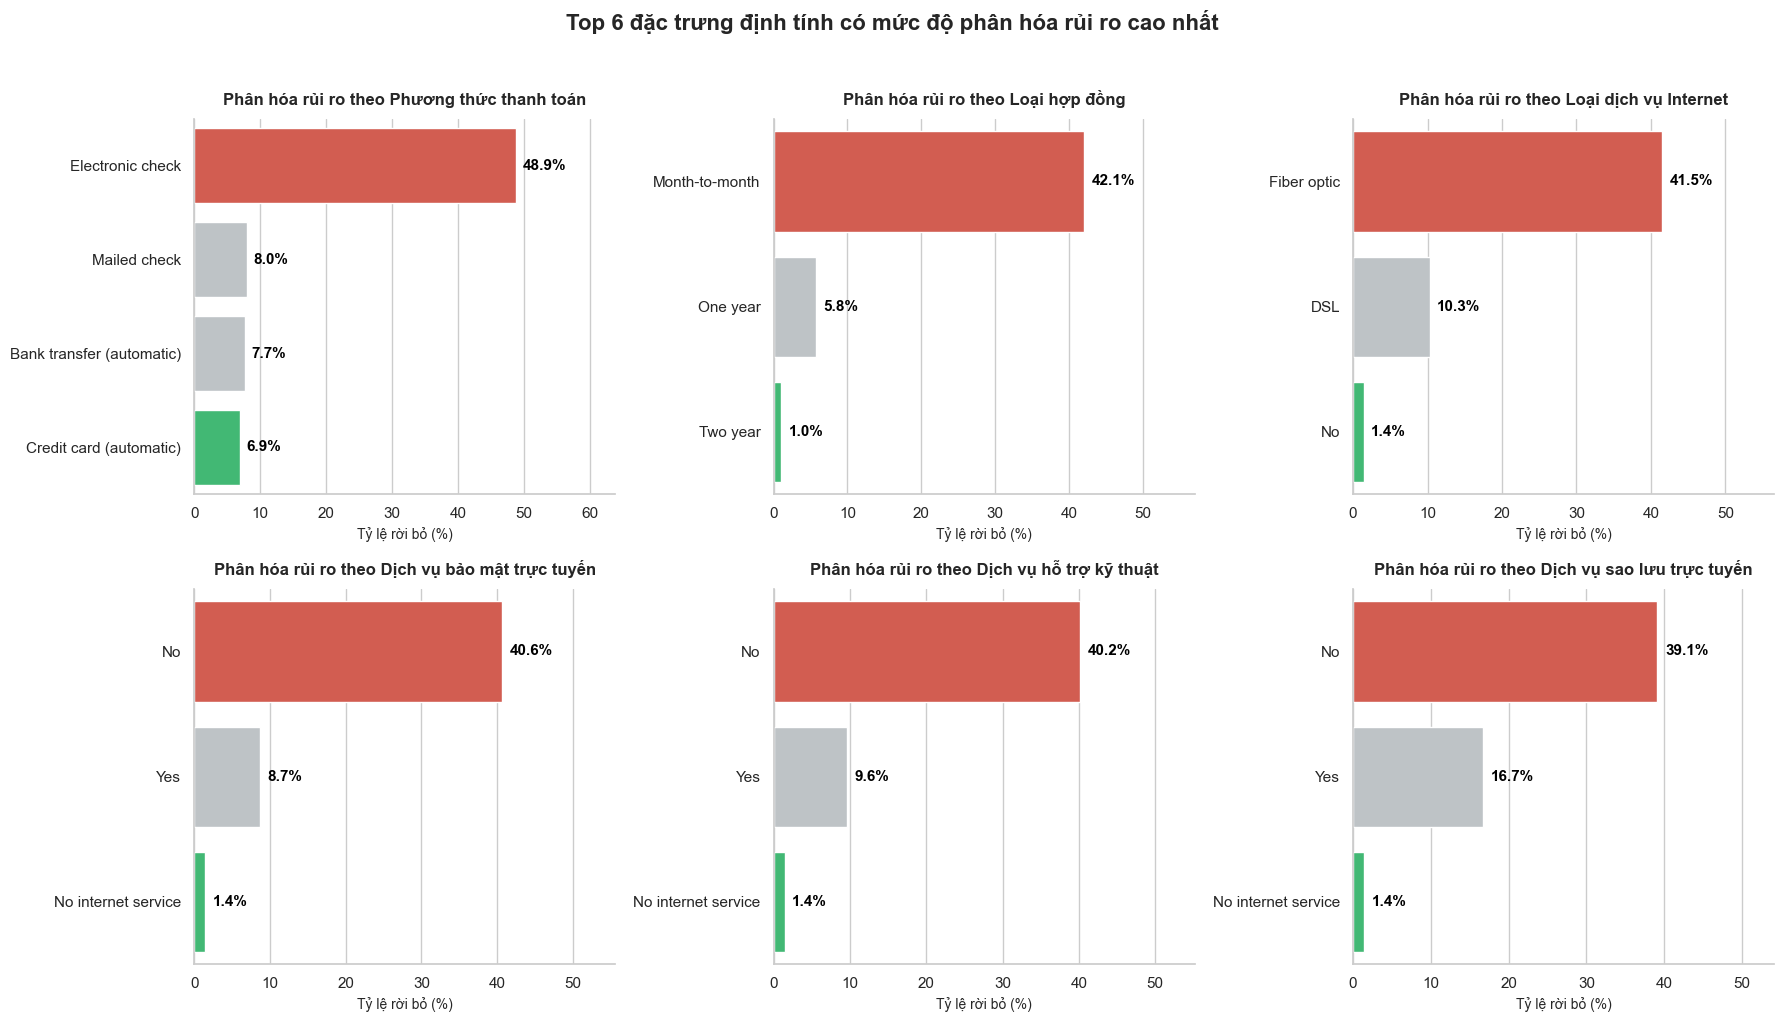

In [32]:
selected_features = [
    "PaymentMethod",
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "OnlineBackup"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10)) 

fig.suptitle("Top 6 đặc trưng định tính có mức độ phân hóa rủi ro cao nhất", fontsize=16, fontweight='bold', y=1.02)
for ax, feature in zip(axes.ravel(), selected_features):
    plot_data = (
        df_train_copy.groupby(feature, dropna=False)["churn_flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index(name="churn_rate")
    )
    
    risk_palette = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_data) - 1 else "#BDC3C7") for i in range(len(plot_data))]

    sns.barplot(
        data=plot_data, 
        y=feature, 
        x="churn_rate", 
        ax=ax,
        palette=risk_palette,
        hue=feature,
        legend=False
    )
    
    ten_tieng_viet = config_features.get(feature, {}).get('name', feature)
    ax.set_title(f"Phân hóa rủi ro theo {ten_tieng_viet}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
    ax.set_ylabel("")

    ax.set_xlim(0, max(50, plot_data["churn_rate"].max() + 15)) 
    
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', 
                    (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', fontsize=11, color='black', fontweight='bold')

    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Nhận xét:** 
- Phương thức thanh toán `PaymentMethod` sở hữu mức phân hóa mạnh nhất với **41.97%**. Khách hàng sử dụng *Electronic check* có tỷ lệ rời bỏ dịch vụ đạt mốc **48.91%**, trong khi nhóm thanh toán tự động qua thẻ tín dụng *Credit card automatic* chỉ đạt **6.93%**.
- Loại hợp đồng `Contract` với sự chênh lệch giữa các nhóm đạt **41.06%**. Khách hàng ký hợp đồng ngắn hạn *Month-to-month* mang rủi ro hủy dịch vụ đến **42.05%**. Ở chiều ngược lại, cam kết dài hạn **2** năm *Two year* gần như triệt tiêu nguy cơ dừng sử dịch vụ với tỉ lệ chỉ **1.00%**.
- Loại dịch vụ Internet `InternetService` ghi nhận khoảng cách **40.11%** giữa nhóm sử dụng hạ tầng mạng cáp quang cao cấp *Fiber optic* với tỉ lệ **41.54%** và *No internet service* với **1.4%**.
- Nhóm khách hàng không đăng ký các dịch vụ an ninh mạng hay hỗ trợ kĩ thuật `OnlineSecurity` và `TechSupport` có rủi ro rời bỏ dịch vụ vượt ngưỡng **40%**, trong khi nhóm tích hợp dịch vụ này giữ tỷ lệ hủy hợp đồng dưới **10%**. 
- Nhóm người cao tuổi tuy có rủi ro rời bỏ dịch vụ cao nhất trong các quan sát với **50.03%**, biên phân hóa tổng thể vẫn giữ ở mức **31.05%**.
- Nhóm tính năng nhiễu với khoảng phân hóa **<10%**:
- Đặc trưng giới tính `gender` gần như không có sự phân hóa với khoảng lệch chỉ **0.57%**, chứng minh hành vi rời bỏ giữa *Nam* và *Nữ* đồng đều tuyệt đối. Các dịch vụ viễn thông cơ bản như `PhoneService` hay `MultipleLines` tương tự cũng thể hiện sự phân hóa rất thấp.

**Note:** Thay đổi từ góc nhìn phân hóa rủi ro **Risk Spread** qua tỷ lệ rời bỏ dịch vụ **Churn Rate** bằng cách phân tích tỷ lệ rời bỏ của từng phân khúc trong nhóm đặc trưng định tính sẽ giúp ta nhận diện chính xác các đặc điểm hành vi độc hại **Toxic traits** đang làm đứt gãy vòng đời khách hàng, tránh việc cào bằng rủi ro trong quá trình **Feature Engineering**.

In [33]:
cat_churn_rows = []

for col in categorical_features:
    tmp = (
        df_train_copy.groupby(col, dropna=False)
        .agg(count=("churn_flag", "size"), churn_rate=("churn_flag", "mean"))
        .reset_index()
        .rename(columns={col: "Giá trị mang rủi ro cao nhất"})
    )
    
    tmp["Đặc trưng"] = col
    tmp["Ý nghĩa đặc trưng"] = config_features.get(col, {}).get('name', feature)
    tmp["Quy mô tệp khách hàng rủi ro"] = (tmp["count"] / len(df_train_copy)) * 100
    tmp["Tỷ lệ rời bỏ nhóm rủi ro"] = tmp["churn_rate"] * 100
    tmp["Tỷ lệ rời bỏ dự kiến"] = (tmp["count"] / len(df_train_copy))*tmp["churn_rate"] *100
    
    cat_churn_rows.append(tmp[["Đặc trưng", "Ý nghĩa đặc trưng", "Giá trị mang rủi ro cao nhất", "Quy mô tệp khách hàng rủi ro", "Tỷ lệ rời bỏ nhóm rủi ro", "Tỷ lệ rời bỏ dự kiến"]])

global_risk_board = pd.concat(cat_churn_rows, ignore_index=True)
top_risk_categories = global_risk_board.sort_values("Tỷ lệ rời bỏ dự kiến", ascending=False).head(10)

display(top_risk_categories.style.format({'Quy mô tệp khách hàng rủi ro': '{:.2f}%', 'Tỷ lệ rời bỏ nhóm rủi ro': '{:.2f}%','Tỷ lệ rời bỏ dự kiến': '{:.2f}%'}).hide(axis="index"))

Đặc trưng,Ý nghĩa đặc trưng,Giá trị mang rủi ro cao nhất,Quy mô tệp khách hàng rủi ro,Tỷ lệ rời bỏ nhóm rủi ro,Tỷ lệ rời bỏ dự kiến
PhoneService,Dịch vụ điện thoại,Yes,93.89%,22.89%,21.49%
Contract,Loại hợp đồng,Month-to-month,50.31%,42.05%,21.16%
Dependents,Tiêu chí người chăm sóc,No,69.74%,29.14%,20.32%
OnlineSecurity,Dịch vụ bảo mật trực tuyến,No,48.72%,40.61%,19.79%
PaperlessBilling,Dịch vụ hóa đơn điện tử,Yes,61.53%,31.94%,19.65%
TechSupport,Dịch vụ hỗ trợ kỹ thuật,No,48.57%,40.16%,19.50%
InternetService,Loại dịch vụ Internet,Fiber optic,45.84%,41.54%,19.04%
PaymentMethod,Phương thức thanh toán,Electronic check,36.25%,48.91%,17.73%
SeniorCitizen,Tiêu chí người cao tuổi,No,88.59%,18.98%,16.81%
OnlineBackup,Dịch vụ sao lưu trực tuyến,No,42.09%,39.10%,16.46%


**Nhận xét:** Với việc tính toán `Tỷ lệ rời bỏ dự kiến` bằng tích của `Quy mô tệp khách hàng` và `Tỷ lệ rời bỏ`, những phân khúc rủi ro thực sự được phát hiện
  - Người cao tuổi có tỷ lệ rời bỏ dịch vụ lên đến **50.0%**, nhưng do quy mô rất nhỏ so với tổng số khách hàng với chỉ **11.41%**, tỷ lệ rời đi dự kiến của họ không nằm trong danh sách này.
  - Các giá trị như `PhoneService` = *Yes* với quy mô **21.49%** hay `Dependents` = *No* khi chiếm **20.32%** khách hàng có tỷ lệ rời bỏ dự kiến cao nhất đơn giản vì sự áp đảo quy mô trong tập dữ liệu, lần lượt là **93.89%** và **69.74%** tổng số khách hàng. Mức rời bỏ của nhóm này thực chất phản ánh tỷ lệ rời bỏ dịch vụ tự nhiên của cả hệ sinh thái.
  - Khi thực hiện loại trừ các yếu tố nền tảng, các phân khúc gây ảnh hưởng nhất đến vòng đời khách hàng lần lượt xuất hiện, mang cả quy mô lớn và tỷ lệ rời bỏ ở mức báo động:
    - Khách hàng trả phí từng tháng `Contract` = *Month-to-month* với tỷ lệ rời bỏ dự kiến đat mức **21.16%**, tức cứ **5** khách hàng của công ty sẽ có **1** người thuộc nhóm hợp đồng ngắn hạn và rời bỏ dịch vụ.
    - Hạ tầng cáp quang `InternetService` = *Fiber optic* xếp sau với **19.04%**.
    - Thanh toán thủ công `PaymentMethod` = *Electronic check* khi đạt **17.73%** tổng số khách hàng.

**Note:** Liệt kê các gói dịch vụ kèm theo các dịch vụ chính.

In [34]:
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

**Note:** Chuyển tiếp sang đánh giá Sức giữ chân **Risk Gap** của hệ sinh thái dịch vụ bổ trợ. Bằng cách tính độ chênh lệch tỷ lệ rời bỏ giữa nhóm không sử dụng và sử dụng — đồng thời loại trừ hoàn toàn tập dữ liệu nhiễu *No internet service* — ta có thể định lượng chính xác sức giữ chân thực tế của từng tiện ích. Phân tích trực quan này sẽ cung cấp căn cứ toán học để quyết định gom nhóm **grouping** các dịch vụ có tín hiệu tương đồng ở giai đoạn **Feature Engineering** tiếp theo.

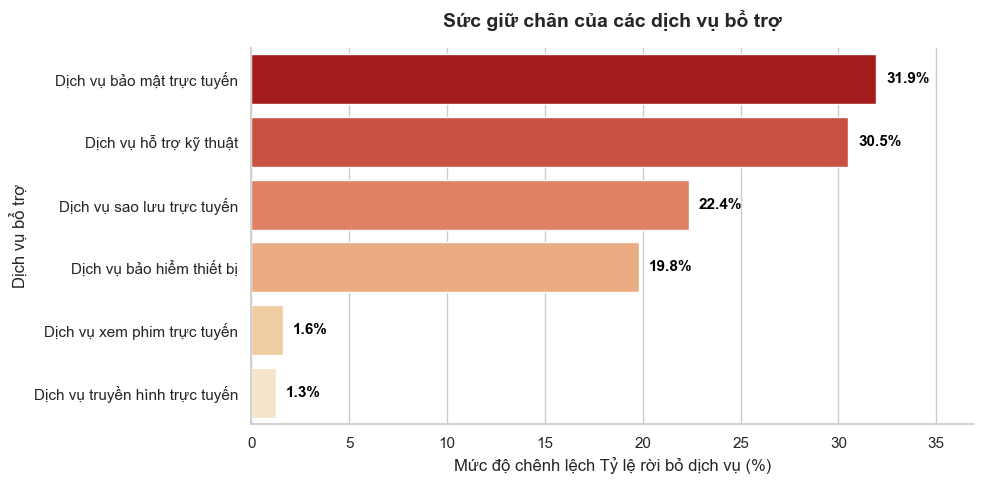

Dịch vụ,Ý nghĩa đặc trưng,Tỷ lệ rời bỏ khi không sử dụng dịch vụ,Tỷ lệ rời bỏ khi sử dụng dịch vụ,Độ chênh lệch
OnlineSecurity,Dịch vụ bảo mật trực tuyến,40.6%,8.7%,31.9%
TechSupport,Dịch vụ hỗ trợ kỹ thuật,40.2%,9.6%,30.5%
OnlineBackup,Dịch vụ sao lưu trực tuyến,39.1%,16.7%,22.4%
DeviceProtection,Dịch vụ bảo hiểm thiết bị,38.1%,18.3%,19.8%
StreamingMovies,Dịch vụ xem phim trực tuyến,29.9%,28.3%,1.6%
StreamingTV,Dịch vụ truyền hình trực tuyến,29.7%,28.5%,1.3%


In [35]:
gap_rows = []

for col in service_cols:
    churn_yes = df_train_copy[df_train_copy[col] == 'Yes']['churn_flag'].mean() * 100
    churn_no = df_train_copy[df_train_copy[col] == 'No']['churn_flag'].mean() * 100
    ten_tieng_viet = config_features.get(col, {}).get('name', col)
    gap_rows.append({
        "Dịch vụ": col,
        "Ý nghĩa đặc trưng": ten_tieng_viet,
        "Tỷ lệ rời bỏ khi không sử dụng dịch vụ": churn_no,
        "Tỷ lệ rời bỏ khi sử dụng dịch vụ": churn_yes,
        "Độ chênh lệch": churn_no - churn_yes
    })

gap_df = pd.DataFrame(gap_rows).sort_values("Độ chênh lệch", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=gap_df, y="Ý nghĩa đặc trưng", x="Độ chênh lệch", palette="OrRd_r", hue="Ý nghĩa đặc trưng", dodge=False, legend=False)

plt.title("Sức giữ chân của các dịch vụ bổ trợ", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mức độ chênh lệch Tỷ lệ rời bỏ dịch vụ (%)", fontsize=12)
plt.ylabel("Dịch vụ bổ trợ", fontsize=12)

plt.xlim(0, gap_df["Độ chênh lệch"].max() + 5)

for p in plt.gca().patches:
    width = p.get_width()
    if width > 0:
        plt.gca().annotate(f'{width:.1f}%',
                           (width + 0.5, p.get_y() + p.get_height() / 2.),
                           ha='left', va='center', fontsize=11, color='black', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

show_cols = [
    "Dịch vụ", 
    "Ý nghĩa đặc trưng", 
    "Tỷ lệ rời bỏ khi không sử dụng dịch vụ", 
    "Tỷ lệ rời bỏ khi sử dụng dịch vụ", 
    "Độ chênh lệch"
]

display(
    gap_df[show_cols].style
    .format({
        'Tỷ lệ rời bỏ khi không sử dụng dịch vụ': '{:.1f}%', 
        'Tỷ lệ rời bỏ khi sử dụng dịch vụ': '{:.1f}%', 
        'Độ chênh lệch': '{:.1f}%'
    })
    .hide(axis="index")
)

**Nhận xét:** Phân tích độ chênh lệch hủy hợp đồng **Risk Gap** của các dịch vụ bổ trợ cho thấy sự trái ngược về sức giữ chân trong hệ sinh thái
- Nhóm dịch vụ Bảo vệ và Hỗ trợ **Security & Support** mang lại hiệu quả tích cực nhất, khi Dịch vụ bảo mật trực tuyến `OnlineSecurity` và Dịch vụ hỗ trợ ký thuật `TechSupport` dẫn đầu về khả năng kéo giảm tỷ lệ rời bỏ xuống mức một con số, từ khoảng **40%** xuống chỉ còn **8.7%** và **9.6%**. Mức chênh lệch hơn **30%** là minh chứng cho khả năng giữ chân khách hàng khi được giao phó sự bảo mật và tiện ích. Nhóm sao lưu và bảo hiểm thiết bị `OnlineBackup` và `DeviceProtection` duy trì hiệu quả ấn tượng với mức xấp xỉ **20%**.
- Trái ngược hoàn toàn với kỳ vọng, việc cung cấp nội dung giải trí `StreamingMovies` và `StreamingTV` gần như không mang đến hiệu quả tích cực đến việc rời đi của khách hàng, khi rủi ro rời bỏ của hai nhóm là gần như tương đương nhau, khi độ chênh lệch chỉ từ **1.3% - 1.6%**. Điều này phản ánh thực tế rằng các dịch vụ Streaming của nhà mạng viễn thông rất dễ bị thay thế bởi các nền tảng bên thứ ba, vì vậy khả năng tạo ra sự trung thành cốt lõi rất khó xảy ra.

## 5.3 Kỹ thuật Đặc trưng (Feature Engineering)

**Note:** Thực hiện chuyển hóa các **Insights** từ quá trình phân tích đơn biến và song biến thành các đặc trưng phái sinh mới, nhằm cô đọng mật độ thông tin rủi ro, tối ưu hóa không gian biểu diễn dữ liệu, từ đó giúp các mô hình **Machine Learning** dễ dàng tính toán và đưa ra các đường phân tách dự đoán tối ưu.

### 5.3.1 Phân khúc hóa Đặc trưng cốt lõi (Binning & Discretization)

**Note:** Rời rạc hóa các biến định lượng phi tuyến tính nhằm khám phá các vùng rủi ro hành vi đặc thù được phát hiện ở mục **5.1 Phân tích nhóm biến định lượng**, giảm thiểu tác động của các giá trị ngoại lai và hỗ trợ các mô hình dạng cây **Tree-based models** phân cắt dữ liệu nhanh chóng hơn.
- Nhóm thời gian gắn bó `tenure_group`: Tách biệt giữa nhóm khách hàng ở giai đoạn trải nghiệm sớm có nguy cơ rời bỏ dịch vụ và các nhóm khách hàng gắn bó lâu dài.
- Nhóm cước phí hàng tháng `charge_segment`: Cô lập phân khúc khách hàng *Phổ thông* quanh mốc **20$** và nhóm khách hàng *Cao cấp* nhạy cảm về giá trên **70$**.

**Note:** Rời rạc hóa Thời gian gắn bó `tenure` với các mốc cắt: 
- *Onboarding* **0-6 tháng**
- *First Year* **6-12 tháng**
- *Second Year* **12-24 tháng**
- *Familiar* **24-48 tháng**
- *Loyal* **trên 48 tháng**

In [36]:

df_train_copy['loyalty_tier'] = pd.cut(
    df_train_copy['tenure'], 
    bins=[0, 6, 12, 24, 48, float('inf')], 
    labels=['Onboarding (0-6 tháng)', 'First Year (7-12 tháng)', 'Second Year (13-24 tháng)', 'Familiar (25-48 tháng)', 'Loyal (trên 48 tháng)'],
    include_lowest=True
)

**Note:** Rời rạc hóa Cước phí hàng tháng `MonthlyCharges` với các mốc cắt
- *Budget* **0-35$**
- *Standard* **35-70$**
- *Premium* **trên 70$**

In [37]:
df_train_copy['charge_segment'] = pd.cut(
    df_train_copy['MonthlyCharges'], 
    bins=[0, 35, 70, float('inf')], 
    labels=['Budget (0-35$)', 'Standard (35-70$)', 'Premium (trên 70$)'],
    include_lowest=True
)

**Note:** Đổi tên đặc trưng nhằm sử dụng cho mục đích hiển thị

In [38]:
new_features = {
    'loyalty_tier': ('Mức độ gắn bó'),
    'charge_segment': ('Phân khúc cước phí')
}

**Note:** Thông thường, các đặc trưng mới sẽ được đưa ngay đến phần tính toán hệ số tương quan để kiểm tra đa cộng tuyến và so sánh độ tương quan của đặc trưng mới và cũ so với biến mục tiêu. Tuy nhiên, để đảm bảo `loyalty_tier` và `charge_segment` không bị triệt tiêu thông tin lẫn nhau và thực sự tạo ra các vùng cô lập rủi ro có ý nghĩa hành vi, ta trực quan hóa sự tương tác giữa cặp đặc trưng này với đặc trưng `Churn` bằng một ma trận tương tác Heatmap. Đây là Kỹ thuật Kiểm chứng Tính giao thoa đặc trưng **Interaction Validation**

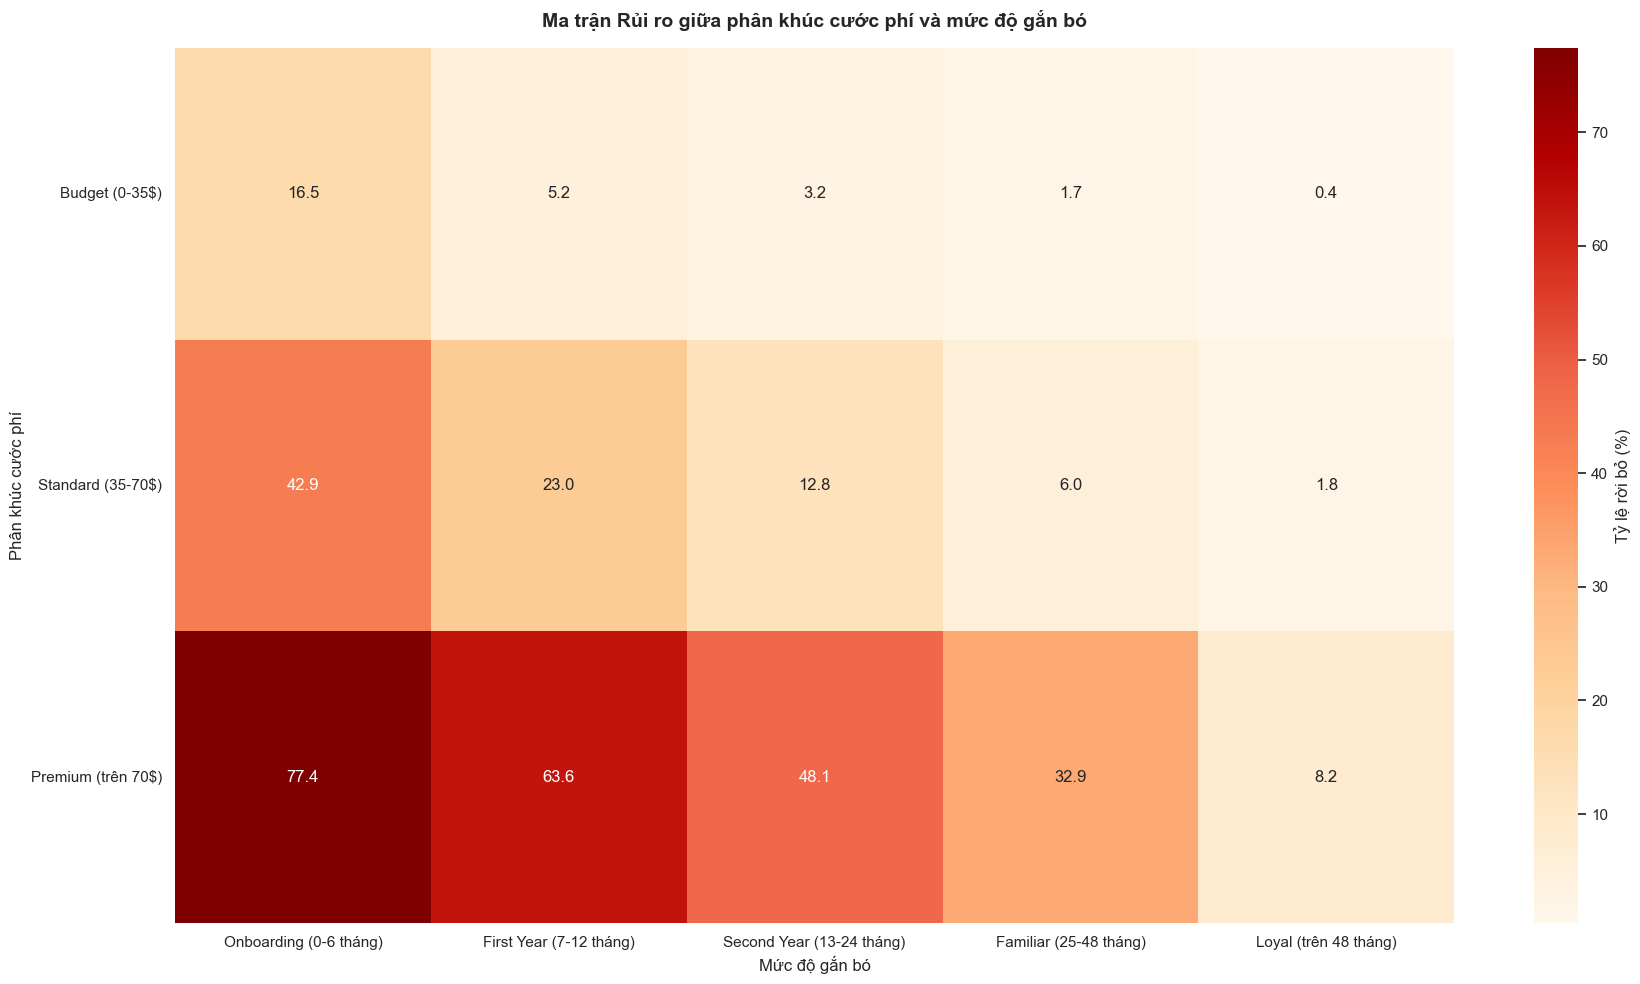

In [39]:
pivot_risk = pd.pivot_table(
    df_train_copy, 
    values='churn_flag', 
    index='charge_segment', 
    columns='loyalty_tier', 
    aggfunc='mean'
) * 100

plt.figure(figsize=(18, 10))
sns.heatmap(pivot_risk, annot=True, fmt=".1f", cmap="OrRd", cbar_kws={'label': 'Tỷ lệ rời bỏ (%)'})
plt.title("Ma trận Rủi ro giữa phân khúc cước phí và mức độ gắn bó", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Phân khúc cước phí", fontsize=12)
plt.xlabel("Mức độ gắn bó", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét:**  
Việc rời rạc hóa các đặc trưng định lượng thành `loyalty_tier` và `charge_segment` không chỉ giúp đơn giản hóa không gian biểu diễn của mô hình mà còn tạo ra hiệu ứng giao thoa rủi ro **Compounding Risk Effect** cực kỳ rõ nét thông qua ma trận Heatmap:
- Vùng rủi ro cộng hưởng lớn xuất hiện ở nhóm khách hàng mới *Onboarding (0-6 tháng)* sử dụng phân khúc dịch vụ *Premium (trên 70$)* với tỷ lệ rời bỏ lên đến mức báo động **77.4%**. Tín hiệu này chỉ ra rằng áp lực chi phí cao giai đoạn mới tiếp xúc dịch vụ chính là sức ép mạnh nhất khiến khách hàng ảnh hưởng đến trải nghiệm và rời bỏ dịch vụ.
- Khi quan sát xu hướng theo chiều ngang của phân khúc *Premium (trên 70$)*, rủi ro rời bỏ dịch vụ có xu hướng giảm, tỷ lệ nghịch với thời gian gắn bó từ mức **77.4%** giai đoạn 0-6 tháng xuống còn **48.1%** giai đoạn năm hai và đạt mức an toàn **8.2%** khi đã trải nghiệm dịch vụ trên **2** năm. Điều này chứng minh khách hàng không hoàn toàn rời đi chỉ vì giá cả khi áp lực chi phí sẽ được giảm đáng kể khi khách hàng hòa mạng sâu và nhận ra giá trị thực tế từ hệ sinh thái dịch vụ.
- Ở chiều hướng ngược lại, nhóm khách hàng thuộc phân khúc *Budget (0-35$)* duy trì mức rủi ro cực kỳ thấp, giảm dần theo cấp số nhân từ **16.5%** về mức **0.4%** ở nhóm *Trung thành*. Đây là nhóm khách hàng có mức độ gắn kết tự nhiên với dịch vụ cao nhất do ít phải chịu áp lực tài chính đột ngột.

**Kết luận:** Đặc trưng phái sinh `loyalty_tier` và `charge_segment` đã thành công phân loại các nhóm hành vi phi tuyến tính một cách xuất sắc. Sự phân hóa rủi ro giữa các ô trên ma trận Heatmap là minh chứng rõ nét cho sự dày đặc mật độ thông tin **Information Density** của hai đặc trưng này.

### 5.3.2. Xây dựng Đặc trưng Tài chính & Áp lực Cước phí (Financial Ratios & Cost Metrics)

**Note:** Xây dựng các chỉ số tương tác nhằm phản ánh áp lực kinh tế ngắn hạn, nguy cơ sốc giá và đơn giá dịch vụ thực tế mà khách hàng đang gánh chịu. Các đặc trưng định lượng liên tục này giúp phân tích sâu hơn các thuộc tính hành vi nhạy cảm về giá của từng nhóm đối tượng.
- *Tỷ lệ chi phí trên thời gian gắn bó Logarit hóa* `charge_to_tenure_ratio_log` đánh giá ngưỡng chịu đựng tài chính của khách hàng. Thực hiện phép biến đổi Logarit nhằm xử lý hiện tượng lệch phải của dữ liệu. Giá trị càng cao càng thể hiện rõ rủi ro ngợp chi phí đối với những người dùng mới có cước tháng đắt đỏ.
- *Tỷ lệ sốc cước* `bill_shock_ratio` thể hiện mức độ chênh lệch giữa cước tháng hiện tại với chi phí trung bình hàng tháng. Khi lớn hơn **1** tỷ lệ này báo hiệu việc khách hàng vừa trải qua đợt tăng giá hoặc hết hạn khuyến mãi, dẫn đến tâm lý sốc và dễ hủy hợp đồng.
- *Chi phí trung bình trên mỗi dịch vụ* `average_cost_per_service` thể hiện chi phí thực tế dựa trên tổng số dịch vụ đang sử dụng, giúp phân biệt nhóm khách hàng tận hưởng một hệ sinh thái giá rẻ với nhiều dịch vụ và nhóm khách hàng gánh cước phí cao nhưng chỉ hưởng một số dịch vụ cốt lõi.

**Note:** Đếm tổng số dịch vụ khách hàng đang sử dụng. `total_active_services` được định nghĩa bao gồm cả các dịch vụ cơ bản như `InternetService` và `PhoneService`. Vì vậy, những trường hợp khách hàng không sử dụng bất cứ dịch vụ nào và mang giá trị **0** là nhóm **khách hàng ma**, đã bị loại bỏ ở mục **3.3 Kiểm tra tính hợp lệ biến định tính (Categorical Features Sanity Check)**, *Chi phí trung bình trên mỗi dịch vụ* không gặp lỗi chia cho **0** **ZeroDivisionError**.

In [40]:
def count_active_services(row):
    count = 0
    if row['InternetService'] in ['DSL', 'Fiber optic']: count += 1
    if row['PhoneService'] == 'Yes': count += 1
    for col in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']:
        if row[col] == 'Yes': count += 1
    return count

df_train_copy['total_active_services'] = df_train_copy.apply(count_active_services, axis=1)

**Note:** Xây dựng các đặc trưng tài chính mới
- *Log Tỷ lệ áp lực chi phí*  
`charge_to_tenure_ratio_log`$=log($`MonthlyCharges`$/$`tenure`$)$
- *Tỷ lệ sốc cước*  
`bill_shock_ratio`$=$`MonthlyCharges`$/($ `TotalCharges`$/$`tenure`$)$
- *Đơn giá dịch vụ thực tế*  
`average_cost_per_service`$=$`MonthlyCharges`$/$ `total_active_services`

In [41]:
df_train_copy['charge_to_tenure_ratio_log'] = np.log1p(df_train_copy['MonthlyCharges'] / df_train_copy['tenure'])

historical_monthly_average = df_train_copy['TotalCharges'] / df_train_copy['tenure']
df_train_copy['bill_shock_ratio'] = df_train_copy['MonthlyCharges'] / historical_monthly_average

df_train_copy['average_cost_per_service'] = df_train_copy['MonthlyCharges'] / df_train_copy['total_active_services']

financial_ratios = ['charge_to_tenure_ratio_log', 'bill_shock_ratio', 'average_cost_per_service']

**Note:** Trực quan hóa các chỉ số tài chính thông qua biểu đồ phân bố mật độ KDE. Việc này đóng vai trò như bước kiểm tra đầu tiên **Sanity Check** để kiểm tra khả năng dự đoán rủi ro của các chỉ số trước khi đưa vào huấn luyện mô hình. Đặc trưng nào có độ phân tách tín hiệu **Signal Separation** giữa hai lớp **0** và **1** lớn sẽ được ưu tiên giữ lại.

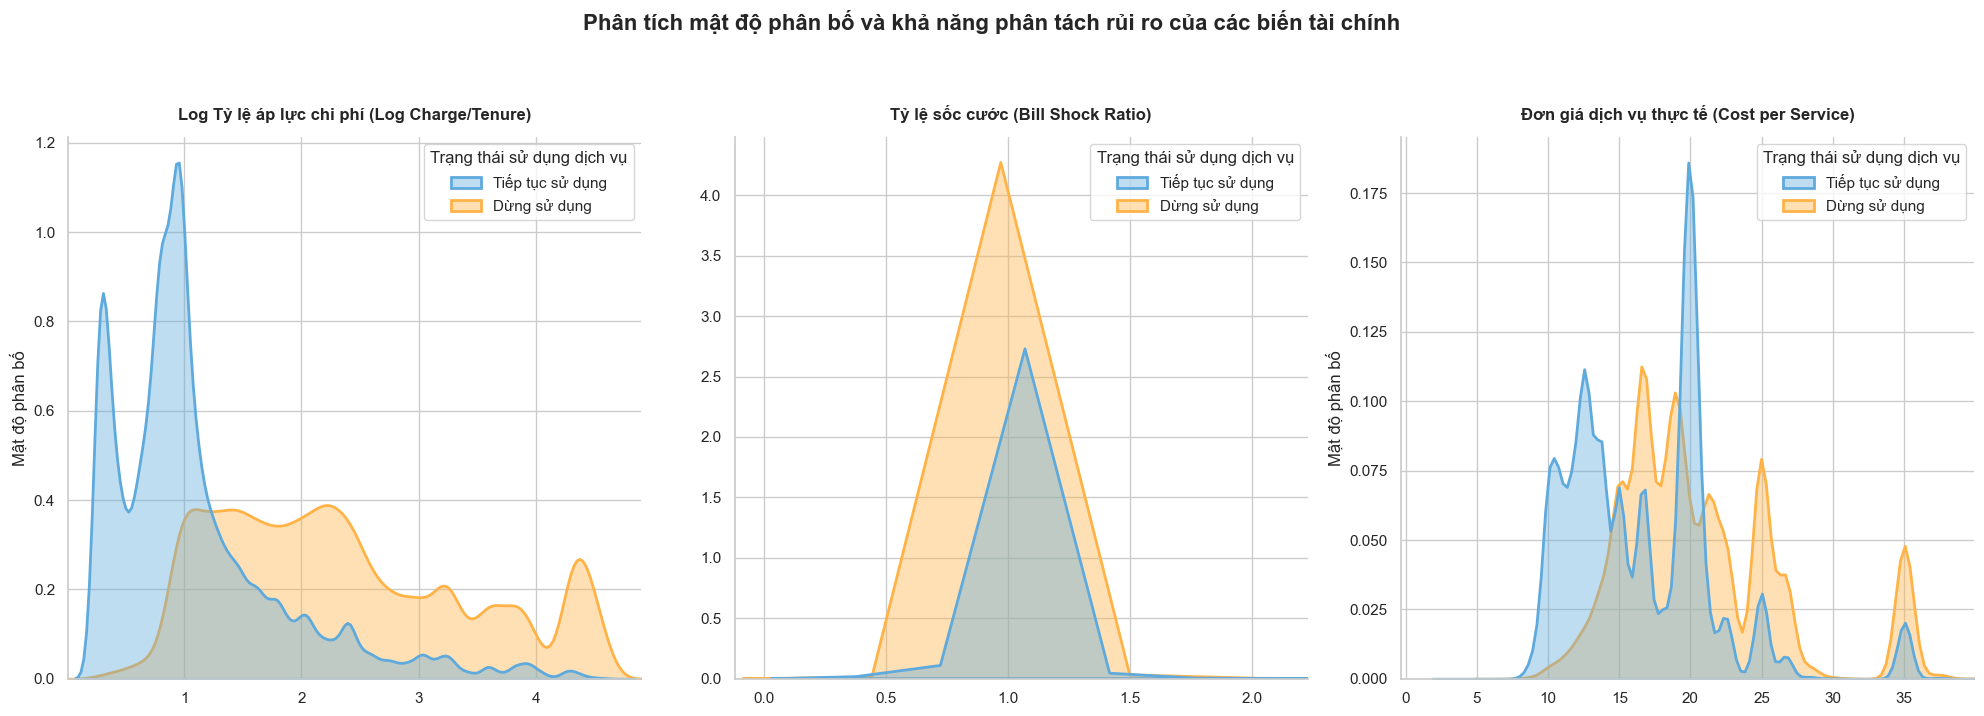

In [42]:
financial_labels = {
    'charge_to_tenure_ratio_log': 'Log Tỷ lệ áp lực chi phí (Log Charge/Tenure)',
    'bill_shock_ratio': 'Tỷ lệ sốc cước (Bill Shock Ratio)',
    'average_cost_per_service': 'Đơn giá dịch vụ thực tế (Cost per Service)'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

fig.suptitle("Phân tích mật độ phân bố và khả năng phân tách rủi ro của các biến tài chính", 
             fontsize=16, fontweight='bold', y=1.02)

churn_palette = {0: "#5FAADD", 1: "#FFB347"}
axes_flat = axes.flatten()

for i, col in enumerate(financial_labels.keys()):
    ax = axes_flat[i]

    sns.kdeplot(
        data=df_train_copy, 
        x=col, 
        hue='churn_flag', 
        hue_order=[0, 1],
        fill=True, 
        palette=churn_palette, 
        common_norm=False, 
        linewidth=2,
        alpha=0.4,
        ax=ax
    )
    
    title_vn = financial_labels.get(col, col)
    ax.set_title(title_vn, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Mật độ phân bố" if i % 2 == 0 else "")
    
    if ax.get_legend():
        ax.get_legend().set_title("Trạng thái sử dụng dịch vụ")
        for text, label in zip(ax.get_legend().get_texts(), ['Tiếp tục sử dụng', 'Dừng sử dụng']):
            text.set_text(label)
    
    min_val = df_train_copy[col].min()
    if col not in ['tenure', 'charge_to_tenure_ratio_log']:
        q99 = df_train_copy[col].quantile(0.999)
        margin = (q99 - min_val) * 0.1 
        ax.set_xlim(min_val - margin, q99 + margin)
    else:    
        max_val = df_train_copy[col].max()
        margin = (max_val - min_val) * 0.05
        ax.set_xlim(min_val - margin, max_val + margin)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**Nhận xét:**  
- Ở **Biểu đồ Log Tỷ lệ Áp lực chi phí**, phân phối của hai nhóm tách rời một cách hoàn hảo. Nhóm khách hàng tiếp tục sử dụng dịch vụ màu xanh tập trung thành các đỉnh nhọn ở vùng giá trị thấp, trong khi nhóm rời bỏ dịch vụ màu cam tạo thành một dải phân phối bẹt và kéo dài về bên phải. Điều này khẳng định mức độ ngợp chi phí là một rủi ro khiến khách hàng rời bỏ dịch vụ.
- Trái ngược với kỳ vọng ban đầu, **Biểu đồ Tỷ lệ Sốc cước** cho thấy hai đường phân phối đè khít lên nhau tạo thành một đỉnh duy nhất tại mốc quanh **1.0**, phản ánh rằng đa số khách hàng sử dụng gói cước cố định. Do không có sự phân hóa tín hiệu, đặc trưng này đã trở thành nhiễu **Noise** và cần được loại bỏ.
- **Biểu đồ Đơn giá Dịch vụ Thực tế** thể hiện một phân phối đa đỉnh **Multi-modal** rất phức tạp. Tuy nhiên, ở các vùng đơn giá cao như từ mốc **25** trở lên, nhóm khách hàng rời bỏ dịch vụ hoàn toàn áp đảo. Khách hàng nhạy cảm về giá không phải vì tổng hóa đơn cao, mà vì cảm thấy số tiền bỏ ra không xứng đáng với tiện ích nhận lại, yếu tố này có thể là do họ không nằm trong hệ sinh thái Combo giá rẻ.

**Kết luận:** Quá trình **Feature Engineering** nhóm biến định lượng đã mang lại hiệu quả khi các đặc trưng phái sinh `charge_to_tenure_ratio_log` và `average_cost_per_service` sở hữu mật độ thông tin **Information Density** cực cao với khả năng phân loại lớp phi tuyến tính xuất sắc. Tuy nhiên trong quá trình nãy cũng xuất hiện `bill_shock_ratio` không mang lại lượng thông tin hữu ích **Information Gain** và sẽ được loại bỏ ở bước **Feature Pruning** nhằm tinh gọn không gian đặc trưng **Feature Space** và tối ưu hóa hiệu suất dự đoán ở giai đoạn sau.

### 5.3.3. Số hóa Hệ sinh thái & Thiết lập Cờ Rủi ro (Ecosystem Scoring & Risk Flags)

**Note:** Dựa trên **Insight** phần **5.2 Phân tích nhóm biến định tính (Categorical Features vs Target)**, hành vi rời bỏ của khách hàng bị chi phối mạnh mẽ bởi hai yếu tố
    - Các dịch vụ Bảo vệ & Hỗ trợ `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection` có mức độ chênh lệch tỷ lệ rời bỏ dịch vụ cao, thể hiện sức giữ chân tốt. Ngược lại, nhóm dịch vụ Giải trí `StreamingMovies`, `StreamingTV` không thể hiện khác biệt quá lớn giữa hai nhóm. Việc so sánh một cách tương đồng các nhóm này có thể gây loãng thông tin.
    - Việc thanh toán thủ công hàng tháng bằng `Electronic check`, `Mailed check` có thể gây ra bất tiện, dẫn đến rủi ro rời bỏ cao, trong khi các phương thức thanh toán tự động khắc phục các điểm yếu này và giữ chân khách hàng một cách hiệu quả.  
Từ các phát hiện nói trên, ta thực hiện phân rã và xây dựng các bộ tín hiệu rủi ro chuyên biệt bao gồm hệ thống điểm số tích lũy `security_score`, `streaming_score`, các cờ rủi ro `zero_supportive_service`, `manual_payment` cùng với siêu cờ `composite_risk_profile` để cô lập các vùng rủi ro nhạy cảm này.

**Note:** Xây dựng thang điểm tích lũy hệ sinh thái **Ecosystem Scoring** nhằm định lượng hóa mức độ gắn kết của khách hàng. Đặc biệt, để loại trừ triệt để ảo giác thống kê **Confounding Bias** gây ra bởi nhóm khách hàng không có hạ tầng mạng, hệ thống điểm thiết lập mốc cơ sở **-1** đối với nhóm này
- Điểm Khiên bảo vệ `security_score`: Thang điểm [-1, 0, 1, ..., 4], tổng hợp từ **4** dịch vụ bảo vệ và hỗ trợ, là nhóm đóng vai trò thiết yếu trong việc giữ chân khách hàng.
- Điểm Giải trí `streaming_score`: Thang điểm [-1, 0, 1, 2], tổng hợp từ **2** dịch vụ giải trí thuần túy, vốn mang mức chênh lệch rủi ro thấp và dễ bị thay thế.  
- Quy ước: Điểm **-1** = Không có hạ tầng Internet; Điểm **0** = Có hạ tầng Internet nhưng từ chối đăng ký; Điểm **>0** = Số lượng tiện ích đang sử dụng.

In [43]:
protective_cols = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
df_train_copy['security_score'] = (df_train_copy[protective_cols] == 'Yes').sum(axis=1)
df_train_copy.loc[df_train_copy['InternetService'] == 'No', 'security_score'] = -1

streaming_cols = ['StreamingTV', 'StreamingMovies']
df_train_copy['streaming_score'] = (df_train_copy[streaming_cols] == 'Yes').sum(axis=1)
df_train_copy.loc[df_train_copy['InternetService'] == 'No', 'streaming_score'] = -1

**Note:** Thiết lập các cờ rủi ro **Risk Flag** nhằm cô lập các vùng rủi ro
- *Cờ Không có dịch vụ hỗ trợ* `zero_supportive_service` quan sát nhóm sử dụng dịch vụ Internet nhưng không tích hợp bất cứ dịch vụ bổ sung nào.
- *Cờ Thanh toán chủ động/thủ công* `manual_payment` nhằm cô lập nhóm thanh toán thủ công bằng *Electronic check*, *Mailed check*
- *Siêu cờ tổ hợp* `composite_risk_profile` mang giá trị **1** nếu khách hàng mang các yếu tố có rủi ro cao nhất: Thanh toán theo tháng và Sử dụng cáp quang.

In [44]:
df_train_copy['zero_supportive_service'] = (df_train_copy['security_score'] == 0).astype(int)

manual_methods = ['Electronic check', 'Mailed check']
df_train_copy['manual_payment'] = df_train_copy['PaymentMethod'].isin(manual_methods).astype(int)

df_train_copy['composite_risk_profile'] = (
    (df_train_copy['Contract'] == 'Month-to-month') & 
    (df_train_copy['InternetService'] == 'Fiber optic')  
).astype(int)

**Note:** Trực quan hóa phân phối rủi ro **Risk Spread Analysis** thông qua hai cấu trúc chuyên biệt: 
- Hệ thống điểm số tích lũy `security_score`, `streaming_score` để quan sát xu hướng rủi ro theo nấc thang dịch vụ.
- Hệ thống cờ hiệu rủi ro `less_supportive_service`, `manual_payment`, `composite_risk_profile` để đánh giá mức độ rủi ro khi xuất hiện cùng lúc các điều kiện vốn đã mang rủi ro cao.

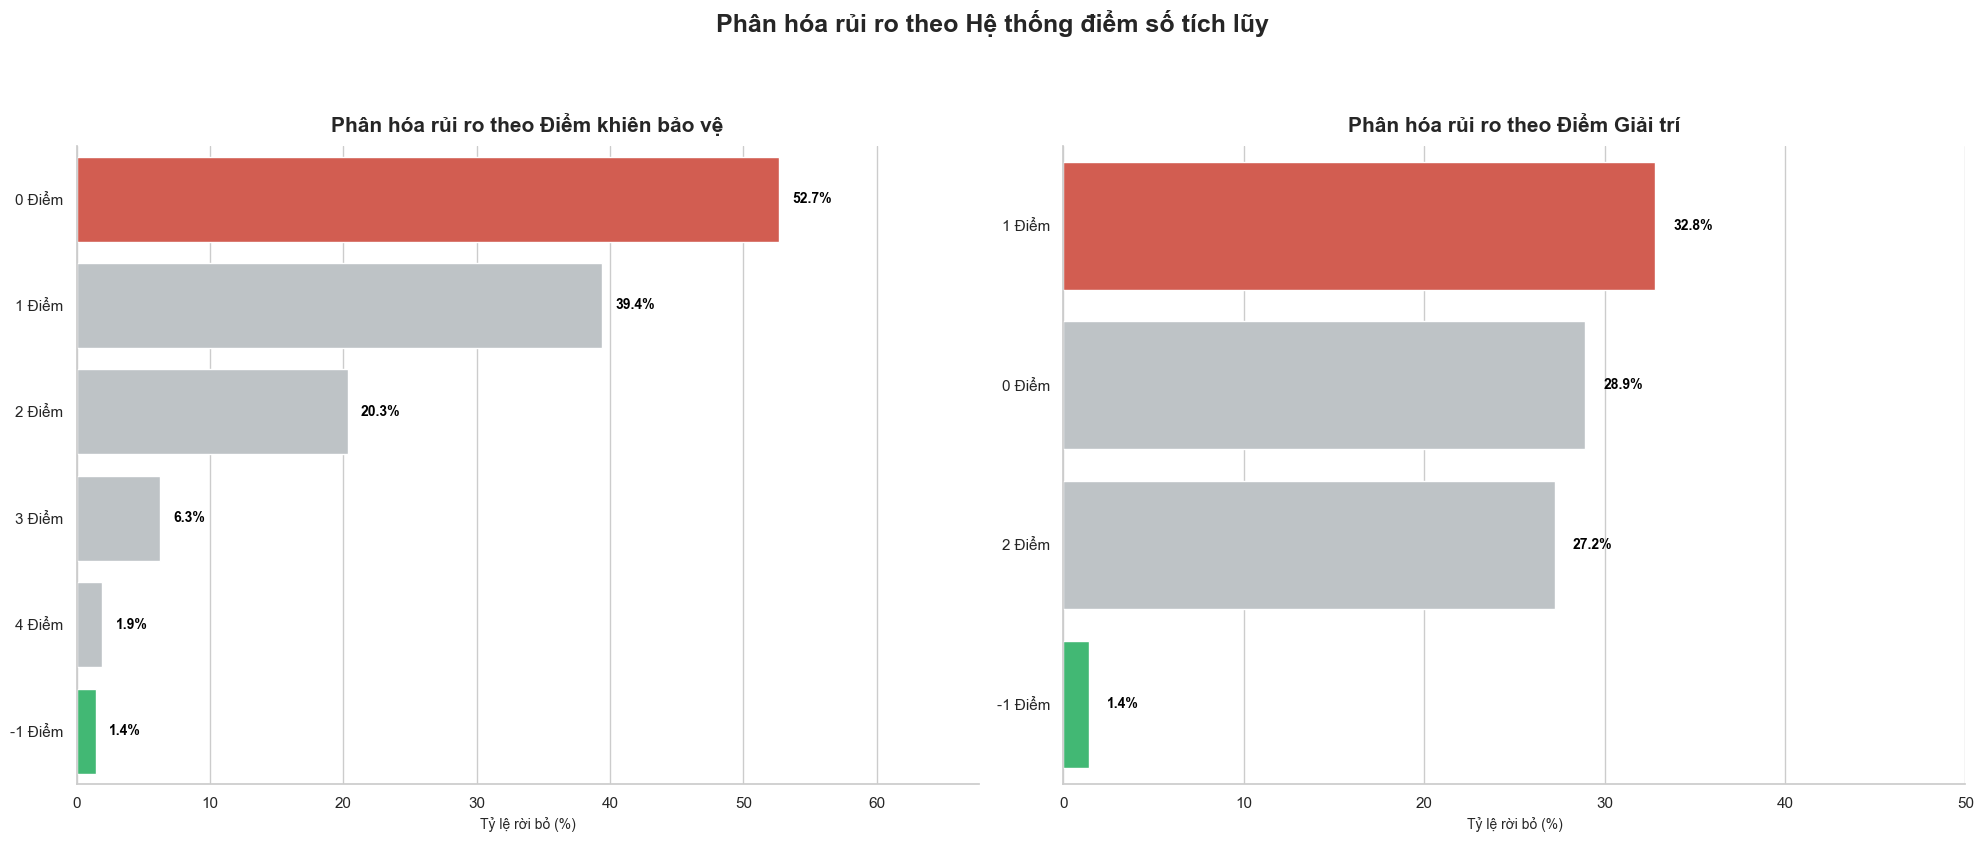

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8)) 
fig.suptitle("Phân hóa rủi ro theo Hệ thống điểm số tích lũy", fontsize=18, fontweight='bold', y=1.05)

plot_sec = df_train_copy.groupby("security_score")["churn_flag"].mean().mul(100).sort_values(ascending=False).reset_index(name="churn_rate")
plot_sec["security_score_lbl"] = plot_sec["security_score"].astype(str) + " Điểm"

palette_sec = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_sec) - 1 else "#BDC3C7") for i in range(len(plot_sec))]

sns.barplot(data=plot_sec, y="security_score_lbl", x="churn_rate", ax=axes[0], palette=palette_sec, hue="security_score_lbl", legend=False)
axes[0].set_title("Phân hóa rủi ro theo Điểm khiên bảo vệ", fontsize=15, fontweight='bold', pad=10)
axes[0].set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
axes[0].set_ylabel("")
axes[0].set_xlim(0, max(50, plot_sec["churn_rate"].max() + 15))

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_width():.1f}%', (p.get_width() + 1, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, color='black', fontweight='bold')
sns.despine(ax=axes[0])

plot_str = df_train_copy.groupby("streaming_score")["churn_flag"].mean().mul(100).sort_values(ascending=False).reset_index(name="churn_rate")
plot_str["streaming_score_lbl"] = plot_str["streaming_score"].astype(str) + " Điểm"

palette_str = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_str) - 1 else "#BDC3C7") for i in range(len(plot_str))]

sns.barplot(data=plot_str, y="streaming_score_lbl", x="churn_rate", ax=axes[1], palette=palette_str, hue="streaming_score_lbl", legend=False)
axes[1].set_title("Phân hóa rủi ro theo Điểm Giải trí", fontsize=15, fontweight='bold', pad=10)
axes[1].set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
axes[1].set_ylabel("")
axes[1].set_xlim(0, max(50, plot_str["churn_rate"].max() + 15))

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_width():.1f}%', (p.get_width() + 1, p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10, color='black', fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

**Nhận xét:** Việc thiết lập mốc cơ sở **-1** đã phân tách thành công yếu tố gây nhiễu **Không sử dụng Internet**, là nhóm có rủi ro rời bỏ thấp tự nhiên, qua đó thể hiện nguy cơ rời bỏ dịch vụ của từng hệ sinh thái
- Điểm Khiên bảo vệ `Security Score`:
    - Nhóm **0** điểm vốn đăng kí Internet nhưng không tích hợp bất kì dịch vụ hỗ trợ hay bảo vệ nào có tỷ lệ rời bỏ đạt mức báo động 52.7%. Sự thiếu hụt phân khúc dịch vụ này khiến trải nghiệm mạng của nhóm trở nên không được như ý, dẫn đến hủy hợp đồng 
    - Ngay khi tích lũy các dịch vụ bảo mật/hỗ trợ, rủi ro rời bỏ dịch vụ giảm mạnh theo cấp số nhân, từ **39.1%** của nhóm đăng kí **1** dịch vụ duy nhất xuống mức **1.4%** khi đã tích hợp cả **4** dịch vụ bổ trợ.
- Điểm Giải trí `Streaming Score`:
    - Trái ngược hoàn toàn với nhóm Khiên bảo vệ, việc bổ sung các dịch vụ giải trí không tạo ra được sức giữ chân như mong đợi. Ngay cả khi khách hàng sở hữu cả **2** dịch vụ Streaming, khả năng hủy hợp đồng vẫn xoay quanh mức báo động **27.2%**, giảm nhẹ so với mức **32.8%** của nhóm **1** điểm và **28.9%** của nhóm **0** điểm.

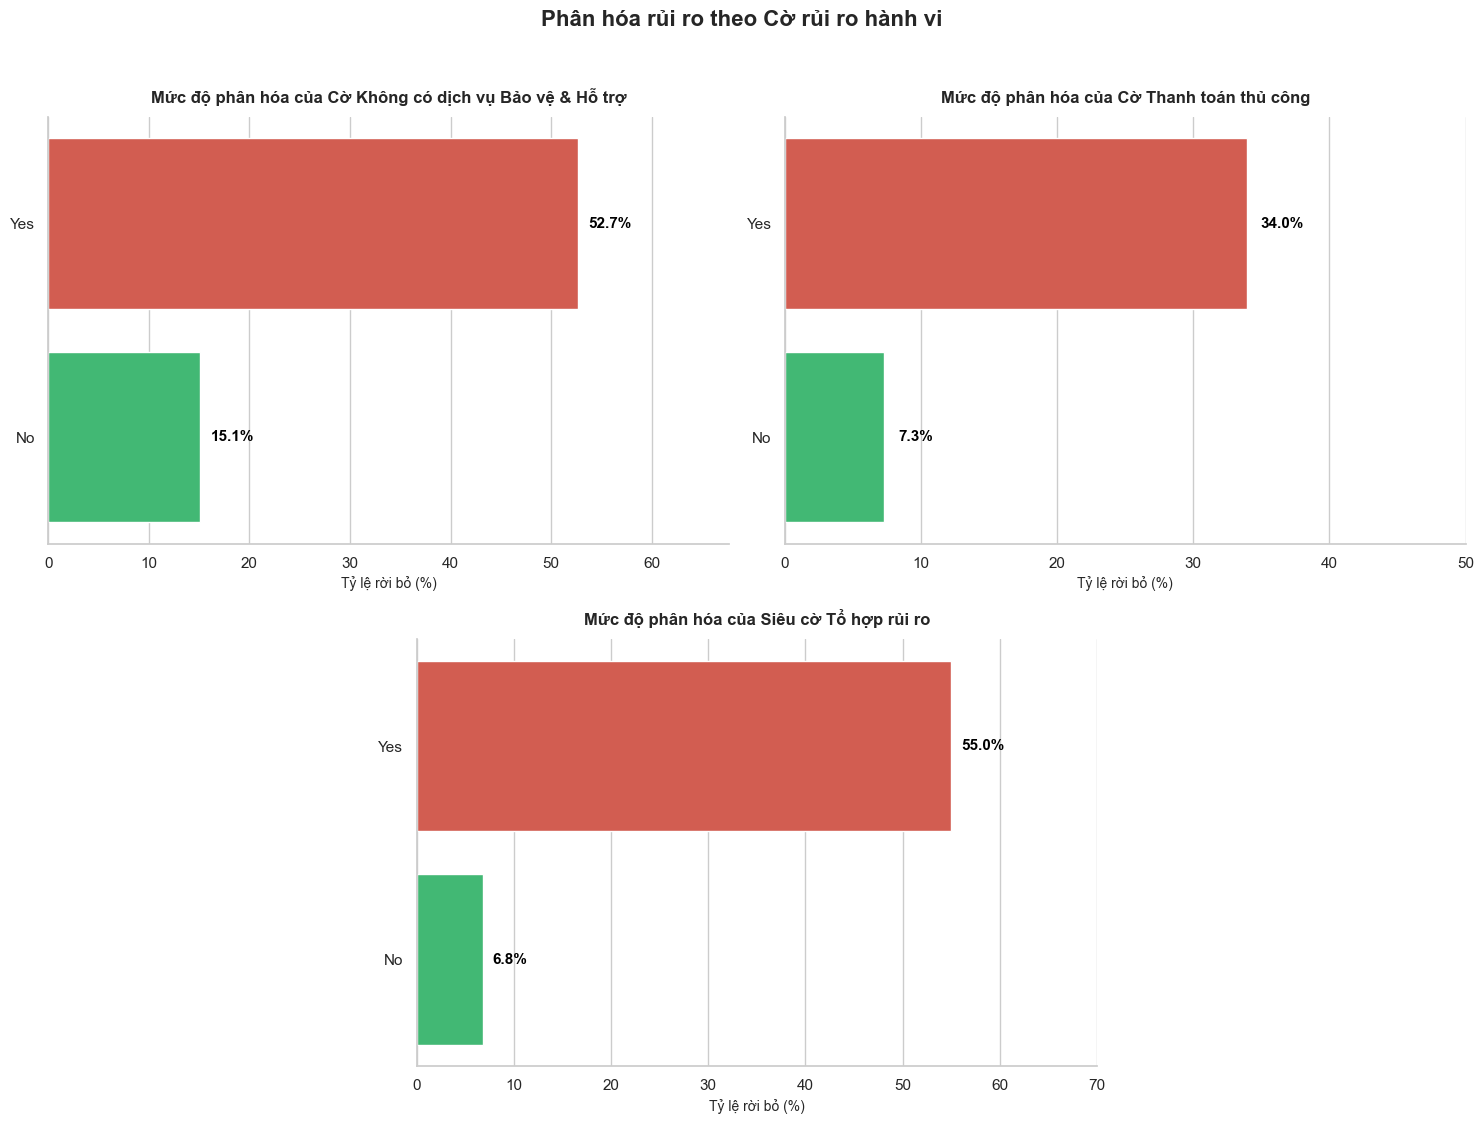

In [46]:
flag_features = ["zero_supportive_service", "manual_payment", "composite_risk_profile"]
flag = {0: "No", 1: "Yes"}
flag_titles = {
    "zero_supportive_service": "Cờ Không có dịch vụ Bảo vệ & Hỗ trợ",
    "manual_payment": "Cờ Thanh toán thủ công",
    "composite_risk_profile": "Siêu cờ Tổ hợp rủi ro"
}

fig = plt.figure(figsize=(15, 11)) 
fig.suptitle("Phân hóa rủi ro theo Cờ rủi ro hành vi", fontsize=16, fontweight='bold', y=1.02)

ax1 = plt.subplot2grid((2, 4), (0, 0), colspan=2)
ax2 = plt.subplot2grid((2, 4), (0, 2), colspan=2)
ax3 = plt.subplot2grid((2, 4), (1, 1), colspan=2)

axes_list = [ax1, ax2, ax3]

for ax, feature in zip(axes_list, flag_features):
    plot_data = df_train_copy.groupby(feature)["churn_flag"].mean().mul(100).sort_values(ascending=False).reset_index(name="churn_rate")
    
    plot_data["display_label"] = plot_data[feature].map(flag)
    
    risk_palette = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_data) - 1 else "#BDC3C7") for i in range(len(plot_data))]

    sns.barplot(
        data=plot_data, 
        y="display_label", 
        x="churn_rate", 
        ax=ax,
        palette=risk_palette,
        hue="display_label",
        legend=False
    )
    
    ax.set_title(f"Mức độ phân hóa của {flag_titles[feature]}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Tỷ lệ rời bỏ (%)", fontsize=10)
    ax.set_ylabel("")
    ax.set_xlim(0, max(50, plot_data["churn_rate"].max() + 15)) 
    
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', 
                    (p.get_width() + 1, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', fontsize=11, color='black', fontweight='bold')

    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

**Nhận xét:** Việc thiết lập các **Cờ rủi ro hành vi** đã khoanh vùng những điểm gãy khiến khách hàng rời bỏ dịch vụ **Churn triggers**
- *Cờ Không có dịch vụ Bảo vệ & Hỗ trợ* `zero_supportive_service`: Với việc quan sát nhóm khách hàng sử dụng mạng nhưng từ chối sử dụng các dịch vụ hỗ trợ và bảo vệ bổ sung, ta phát hiện một vùng rủi ro khiến tỷ lệ rời bỏ lên đến **52.7%** - cao hơn rất nhiều phân khúc còn lại với chỉ **15.1%**.
- *Cờ Thanh toán thủ công* `manual_payment`: Sự bất tiện khi trả phí bằng các phương thức thủ công đẩy mức rủi ro lên đến **34.0%**, đối lập hoàn toàn với mức **7.3%** của hệ thống thanh toán tự động.
- *Siêu cờ Tổ hợp* `composite_risk_profile`là thành quả ấn tượng nhất của quá trình **Feature Engineering**. Sự kết hợp giữa hạ tầng cáp quang đắt đỏ *Fiber Optic* và thời gian hợp đồng ngắn *Month-to-month* tạo ra một vùng cộng hưởng rủi ro đẩy đỉnh này lên mức **55.0%** — cứ 20 người thì có tới 11 người hủy hợp đồng.

### 5.3.4. Định hình Phân khúc Vòng đời & Ràng buộc Gia đình (Demographic & Life-Stage Profile)

**Note:** Quan sát Bảng xếp hạng **Risk Spread** ở mục **5.2 Phân tích nhóm biến định tính (Categorical Features vs Target)**, nhóm *Nhân khẩu học* **Demographics** thể hiện hai góc nhìn hoàn toàn trái ngược về giá trị thông tin:
- `gender` gần như không xuất hiện sự phân hóa rủi ro khi mức chênh lệch **0.57%**. Việc khách hàng là *Nam* hay *Nữ* không thay đổi quyết định rời bỏ dịch vụ. Đặc trưng này mang tính gây nhiễu và sẽ được đưa vào danh sách loại bỏ **Drop** vào các bước sau.
- Các đặc trưng Nhân khẩu học khác với `SeniorCitizen` mang tỷ lệ **31.05%**, `Dependents` với **21.86%** và `Partner` cùng mức rủi ro **19.08%** đều có sự phân hóa rủi ro ở mức tốt. Tuy nhiên, nếu phân tích chúng một cách riêng rẽ, ta sẽ bỏ lỡ hoàn cảnh thực tế của khách hàng. Một người cao tuổi mang rủi ro rời bỏ **50%**, nhưng rủi ro này đến từ việc họ sống đơn độc, loay hoay với sự cố kỹ thuật, hay do nguyên nhân nào khác? Vì vậy, thay vì mã hóa rời rạc, ta gộp biến theo Vòng đời **Life-Stage Grouping**. Bằng cách kết hợp chéo 3 đặc trưng `SeniorCitizen`, `Partner`, `Dependents`, một không gian chân dung khách hàng gồm **4** nhóm được xây dựng thông qua các Cờ rủi ro **Risk Flags**. Đây là phương pháp Tương tác đặc trưng dựa trên tri thức ngành **Domain-Driven Feature Interaction**. 

**Note:** Thực hiện phân tách tập dữ liệu thành **4** phân khúc cốt lõi
- *Người cao tuổi neo đơn* **IsolatedSenior**: [Senior + Độc thân + Không có người phụ thuộc tài chính] thiếu hụt các kỹ năng trong mảng công nghệ, không có gia đình để hỗ trợ tại nhà và linh hoạt trong việc rời bỏ dịch vụ.
- *Người cao tuổi có gia đình* **SupportedSenior**: [Senior + Có gia đình + Có người phụ thuộc tài chính] dù lớn tuổi được bù đắp các kĩ năng cần thiết nhờ các thành viên khác trong gia đình, ít linh hoạt hơn khi rời bỏ dịch vụ.
- *Khách hàng trẻ độc thân* **SingleYouth**: [Không phải Senior + Độc thân + Không có người phụ thuộc tài chính] là nhóm khách hàng linh hoạt trong việc rời bỏ dịch vụ nhất, nhưng có các kiến thức và kỹ năng cần thiết để giải quyết vấn đề khi xảy ra lỗi kĩ thuật.
- *Hộ gia đình trẻ* **NuclearFamily**: [Không phải Senior + Có gia đình + Có người phụ thuộc tài chính] được dự đoán có khả năng rời bỏ dịch vụ thấp nhất, đến từ cả khả năng giải quyết vấn đề và rào cản thay đổi lớn, phần lớn đến từ gia đình.

In [47]:
conditions = [
    (df_train_copy['SeniorCitizen'] == 'Yes') & (df_train_copy['Partner'] == 'No') & (df_train_copy['Dependents'] == 'No'),
    (df_train_copy['SeniorCitizen'] == 'Yes') & ((df_train_copy['Partner'] == 'Yes') | (df_train_copy['Dependents'] == 'Yes')),
    (df_train_copy['SeniorCitizen'] == 'No') & (df_train_copy['Partner'] == 'No') & (df_train_copy['Dependents'] == 'No'),
    (df_train_copy['SeniorCitizen'] == 'No') & ((df_train_copy['Partner'] == 'Yes') | (df_train_copy['Dependents'] == 'Yes'))
]

choices = [
    'Isolated Senior',
    'Supported Senior',
    'Single Youth',
    'Nuclear Family'
]

df_train_copy['demographic_profile'] = np.select(conditions, choices, default='Unidentified')

**Note:** Hàm đổi tên nhãn, sử dụng cho mục đích hiển thị.

In [48]:
demographic_labels = {
    'Isolated Senior': 'Người cao tuổi neo đơn',
    'Supported Senior': 'Người cao tuổi có gia đình',
    'Single Youth': 'Khách hàng trẻ độc thân',
    'Nuclear Family': 'Hộ gia đình trẻ'
}

**Note:**  
Trực quan hóa mức độ phân tách rủi ro **Risk Spread** của biến nén `demographuc_profile` vừa khởi tạo. Biểu đồ trục kép phối hợp giữa tỷ lệ rời bỏ dịch vụ **Bar** và tỷ trọng quy mô mẫu **Line**, giúp kiểm chứng khả năng phân hóa tỷ lệ rời bỏ của 4 nhóm chân dung khách hàng **Customer Personas** trước khi đưa vào mô hình huấn luyện.

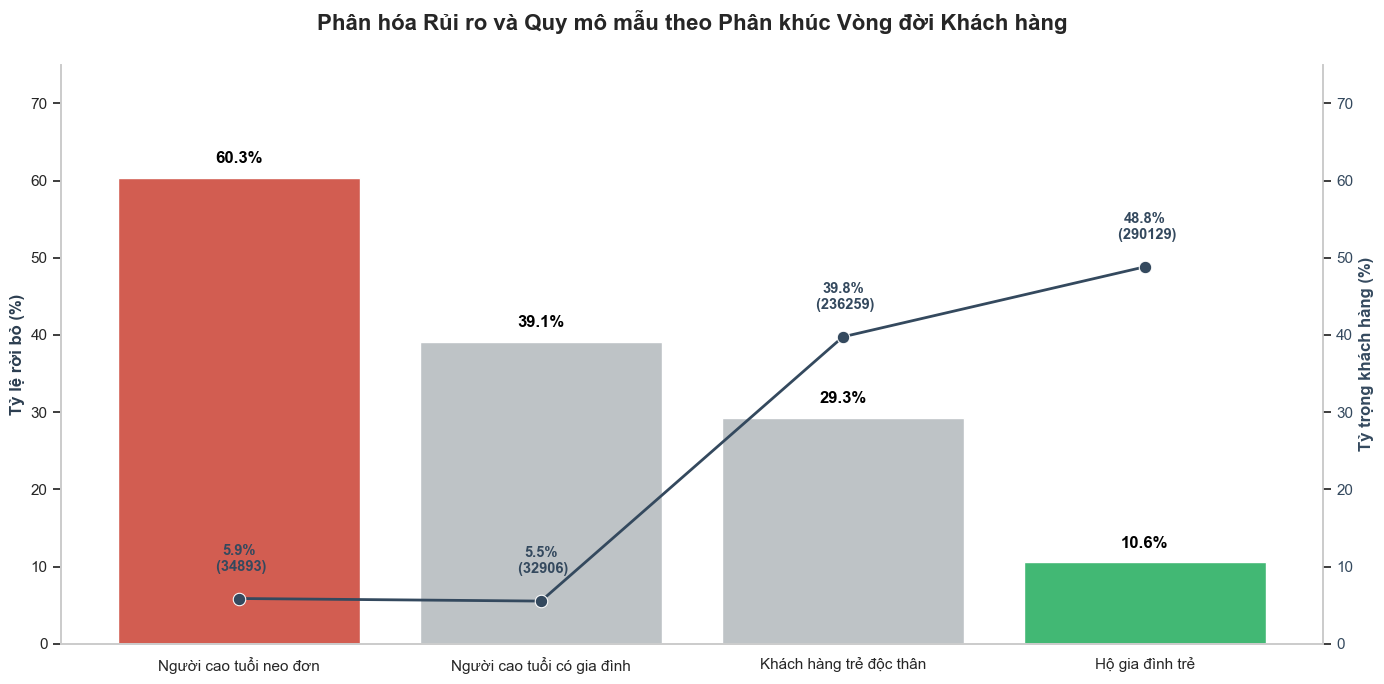

In [49]:

plot_data_demo = df_train_copy.groupby('demographic_profile').agg(
    churn_rate=('churn_flag', lambda x: x.mean() * 100),
    customer_count=('churn_flag', 'count')
).reset_index()

total_customers = plot_data_demo['customer_count'].sum()
plot_data_demo['pct_total'] = (plot_data_demo['customer_count'] / total_customers) * 100
plot_data_demo = plot_data_demo.sort_values('churn_rate', ascending=False).reset_index(drop=True)

risk_palette = ["#E74C3C" if i == 0 else ("#2ECC71" if i == len(plot_data_demo) - 1 else "#BDC3C7") for i in range(len(plot_data_demo))]
line_color = '#34495E'

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=plot_data_demo,
    x=plot_data_demo['demographic_profile'].map(demographic_labels),
    y='churn_rate',
    palette=risk_palette,
    hue='demographic_profile',
    legend=False,
    ax=ax1
)

ax1.set_ylabel('Tỷ lệ rời bỏ (%)', fontsize=12, fontweight='bold', color='#2C3E50')
ax1.set_xlabel('')
ax1.set_ylim(0, 75)

ax2 = ax1.twinx()
sns.lineplot(
    data=plot_data_demo,
    x=plot_data_demo['demographic_profile'].map(demographic_labels),
    y='pct_total',
    color=line_color,
    marker='o',
    markersize=9,
    linewidth=2,
    ax=ax2
)

ax2.set_ylabel('Tỷ trọng khách hàng (%)', fontsize=12, color=line_color, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=line_color)
ax2.set_ylim(0, 75)
for i, row in plot_data_demo.iterrows():
    ax1.annotate(f"{row['churn_rate']:.1f}%", 
                 (i, row['churn_rate'] + 1.5), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

    count_val = row['customer_count']
    offset = 3.2
    ax2.annotate(f"{row['pct_total']:.1f}%\n ({count_val})", 
                 (i, row['pct_total'] + offset), 
                 ha='center', va='bottom', fontsize=10.5, color=line_color, fontweight='bold')

plt.title('Phân hóa Rủi ro và Quy mô mẫu theo Phân khúc Vòng đời Khách hàng', 
          fontsize=16, fontweight='bold', pad=25)

ax1.grid(False)
ax2.grid(False)
sns.despine(ax=ax1, top=True, right=False)
sns.despine(ax=ax2, top=True, right=False)

plt.tight_layout()
plt.show()

**Nhận xét:**  
- Biểu đồ trục kép thể hiện một quy luật vô cùng đắt giá rằng rủi ro rời bỏ dịch vụ tỷ lệ nghịch với quy mô khách hàng. Đây là tín hiệu tốt cho cấu trúc doanh thu khi nhóm có rủi ro cao nhất lại chiếm dung lượng mẫu thấp nhất và ngược lại.
- Phân khúc khách hàng lớn tuổi và sống hoàn toàn độc lập bị cô lập ở vùng rủi ro cực đại với tỷ lệ rời bỏ dịch vụ đạt đỉnh **60.3%**. Thiếu hụt về yếu tố giữ chân do không vướng bận gia đình, tự chủ tài chính cộng với năng lực xử lý sự cố công nghệ hạn chế khiến nhóm này dễ dàng hủy hợp đồng hơn so với tất cả các nhóm khác. Tuy nhiên, về tổng quan, ảnh hưởng của nhóm này bị giảm thiểu đến mức tối đa khi phân khúc này chỉ chiếm **5.9%** tổng số khách hàng.
- Ngay cả khi đối mặt với rào cản tuổi tác, nếu khách hàng sống cùng gia đình hay người phụ thuộc tài chính, rủi ro rời bỏ giảm mạnh từ mức **60.3%** xuống chỉ còn **39.1%**. Sự hỗ trợ trong việc khắc phục lỗi kỹ thuật cùng với rào cản chuyển đổi đóng vai trò quan trọng trong việc giữ chân khách hàng
- Ở chiều hướng khác, nhóm *Hộ gia đình trẻ* chiếm **48.8%** tổng số khách hàng cũng là nhóm an toàn nhất với mức rủi ro chỉ **10.6%**, phần lớn đến từ khả năng xử lí vấn đề kĩ thuật và rào cản chuyển đổi từ gia đình.

**Kết luận:** Biến nén `demographic_profile` tạo ra mức phân hóa rủi ro **Risk Spread** đột phá lên đến **49.7%**, với tỷ lệ rủi ro cao nhất **60.3%** và thấp nhất **10.6%**. Bằng tư duy tương tác đặc trưng theo nghiệp vụ **Domain-Driven Interaction**, các tổ hợp tự nhiên được tinh gọn thành **4** phân khúc chiến lược. Thao tác này triệt tiêu các nhóm thiểu số rời rạc, bảo đảm mật độ thông tin đồng đều trên toàn bộ tập huấn luyện. Việc hợp nhất các đặc trưng nhân khẩu học `SeniorCitizen`, `Partner` và `Dependents` vừa triệt tiêu hoàn toàn rủi ro đa cộng tuyến **Multicollinearity**, vừa đưa ra những nút rẽ nhánh mang khối lượng thông tin lớn **High-gain split nodes** cho các mô hình Cây quyết định **Tree-based Models** **LightGBM**, **XGBoost** ở giai đoạn sau.

### 5.3.5. Tổng kết & Đề xuất Thanh lọc Đặc trưng (Heuristic Feature Pruning Strategy)

**Note:** Thực hiện đóng gói không gian đặc trưng **Feature Space** và đề xuất chiến lược cắt tỉa **heuristic** dựa trên tri thức ngành **Domain-Driven Pruning**. Mục tiêu cốt lõi là tìm kiếm các đặc trưng nguyên bản mang thông tin trùng lặp, hoặc mang nhiễu, từ đó tinh gọn ma trận đầu vào trước khi tiến hành phân tích tương quan và huấn luyện.

**Đánh giá Thực nghiệm & Đề xuất Loại bỏ (Pruning Insights):**
- Loại bỏ các đặc trưng gốc `SeniorCitizen`, `Partner`, `Dependents`, `tenure` và `MonthlyCharges` vì chúng đã được chiết xuất thông tin và hợp nhất thành công vào các đặc trưng tương tác cao cấp, mang tính khái quát hóa cao hơn như `demographic_profile`, `loyalty_tier`, `charge_segment`. Việc giữ lại bản gốc sẽ tạo ra sự dư thừa dữ liệu `Redundancy`, khiến mô hình bị đánh lừa bởi thông tin trùng lặp, làm nhiễu hệ số đóng góp `Feature Importance` và trực tiếp suy giảm năng lực dự đoán trên tập dữ liệu mới.
- Loại bỏ các đặc trưng không mang lại giá trị dự đoán, giúp tinh gọn không gian vector và tránh hiện tượng Bùng nổ số chiều dữ liệu `Curse of Dimensionality`:
    - `gender`: Dữ liệu từ bảng xếp hạng rủi ro chỉ ra rằng giới tính có mức độ phân hóa chỉ **0.57%**. Đặc trưng này hoàn toàn mang tính ngẫu nhiên, lượng thông tin thu được `Information Gain` gần như bằng 0 đối với hành vi rời bỏ dịch vụ.
    - `bill_shock_ratio`: Qua đồ thị mật độ KDE, phân phối của nhóm rời đi và nhóm ở lại đè khít lên nhau tại mốc **1.0**, chứng minh cơ chế thu phí cố định của dịch vụ viễn thông đã vô hiệu hóa hoàn toàn giả thuyết "sốc cước". Thao tác loại bỏ đặc trưng này giúp tránh làm loãng trọng số **Weights** của các đặc trưng cốt lõi khác.

 ### 5.3.6 Kết luận Chương Kỹ thuật Đặc trưng (Feature Engineering Summary):**

- Quá trình xử lý đặc trưng từ mục **5.3.1** đến **5.3.4** đã chuyển hóa thành công các đặc trưng gốc thành một hệ thống tín hiệu cô đọng, bao gồm các biến tài chính thể hiện áp lực chi phí, hệ thống điểm số/cờ hiệu cô lập siêu rủi ro tổ hợp, và đặc trưng chân dung vòng đời gom nhóm các đặc điểm Nhân khẩu học rời rạc nhằm phản ánh thực tế hoàn cảnh của khách hàng.
- Bằng cách thanh lọc đặc trưng **heuristic** tại mục **5.3.5 Tổng kết & Đề xuất Thanh lọc Đặc trưng (Heuristic Feature Pruning Strategy)**, dữ liệu đã được xử lí một phần yếu tố đa cộng tuyến và loãng thông tin. Thông qua bước Phân tích Tương quan tiếp theo nhằm giải quyết triệt để các vấn đề nói trên, dữ liệu đầu vào không chỉ giúp các thuật toán dựa trên Cây như **LightGBM**, **XGBoost** tăng tốc độ hội tụ khi rẽ nhánh, ngăn chặn hiện tượng học vẹt **Overfitting**, mà còn thiết lập một nền tảng dữ liệu sạch chuẩn mực.

## 5.4 Phân tích Tương quan Toàn cục (Global Correlation Analysis)

**Note:** Phân tích tương quan là bước cuối cùng giữa giai đoạn xử lý dữ liệu và giai đoạn huấn luyện thuật toán học máy. Mục tiêu của phần này là chuyển hóa các nhận định trực quan **Visual Insights** ở các phần trước thành những bằng chứng toán học vững chắc. Toàn bộ không gian đặc trưng sẽ được đưa vào một hệ quy chiếu thống kê nhằm chứng minh toán học sự vượt trội về mật độ thông tin của các đặc trưng mới so với các đặc trưng nguyên bản, cũng như tìm kiếm và phát hiện sự rò rỉ hoặc trùng lặp thông tin giữa các biến độc lập. Để đảm bảo tính toàn vẹn của các giả định thống kê, ứng với mỗi kiểu đặc trưng sẽ có một phương pháp tính hệ số phù hợp: **Pearson** cho tương quan tuyến tính, **Spearman** cho đặc trưng thứ bậc và **Cramer's V** cho không gian định tính.

**Note:** Liệt kê các đặc trưng theo phân loại và đổi tên để phục vụ mục đích hiển thị.

In [50]:
continuous_vars = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 
    'charge_to_tenure_ratio_log', 'average_cost_per_service',
    'churn_flag'
]

ordinal_vars = [
    'loyalty_tier', 'charge_segment', 
    'churn_flag'
]

categorical_vars = [
    'SeniorCitizen', 'Partner', 'Dependents',
    'demographic_profile',
    'security_score', 'streaming_score', 'composite_risk_profile', 'zero_supportive_service', 'manual_payment', 
    'churn_flag'
]

feature_mapping = {
    'tenure': 'Thời gian gắn bó',
    'MonthlyCharges': 'Cước phí hàng tháng',
    'TotalCharges': 'Tổng cước phí',
    'charge_to_tenure_ratio_log': 'Log Tỷ lệ Áp lực chi phí',
    'average_cost_per_service': 'Đơn giá Dịch vụ Thực tế',
    'loyalty_tier': 'Mức độ gắn bó',
    'charge_segment': 'Phân khúc Cước phí',
    'SeniorCitizen': 'Tiêu chí người cao tuổi',
    'Partner': 'Tiêu chí bạn đời',
    'Dependents': 'Tiêu chí người chăm sóc',
    'demographic_profile': 'Phân khúc Vòng đời Khách hàng',
    'security_score': 'Điểm Khiên Bảo vệ',
    'streaming_score': 'Điểm Giải trí',
    'composite_risk_profile': 'Siêu cờ Tổ hợp rủi ro',
    'zero_supportive_service': 'Cờ Không có dịch vụ Bảo vệ & Hỗ trợ',
    'manual_payment': 'Cờ Thanh toán thủ công',
    'churn_flag': 'Rủi ro rời bỏ dịch vụ'
}

### 5.4.1. Tương quan Nhóm Định lượng & Thứ bậc (Quantitative & Ordinal Correlation)

**Note:**  
Để phân tích chính xác bản chất của các nhóm dữ liệu dạng số, ta áp dụng kĩ thuật tương ứng với mỗi kiểu đặc trưng
- Sử dụng **Hệ số Pearson ($r$)** nhằm đo lường mức độ tương quan tuyến tính giữa các biến định lượng liên tục nguyên bản như `MonthlyCharges`, `TotalCharges` và các chỉ số tài chính. 
- Sử dụng **Hệ số Spearman ($\rho$)** trong việc định lượng hóa mối quan hệ đơn điệu thứ hạng, phù hợp với các biến rời rạc hóa **Binning** mang tính thứ bậc như `loyalty_tier` hay `charge_segment`.

**Note:** Áp dụng hệ số Pearson $r$ để tìm mức tương quan cũng như chiều hướng của mối quan hệ tuyến tính giữa các biến định lượng liên tục nhằm chỉ ra các cặp đặc trưng trùng lặp thông tin nghiêm trọng, cũng như khảo sát sơ bộ năng lực phân tách **Predictive Power** của các chỉ số tài chính đối với biến mục tiêu `Churn`.

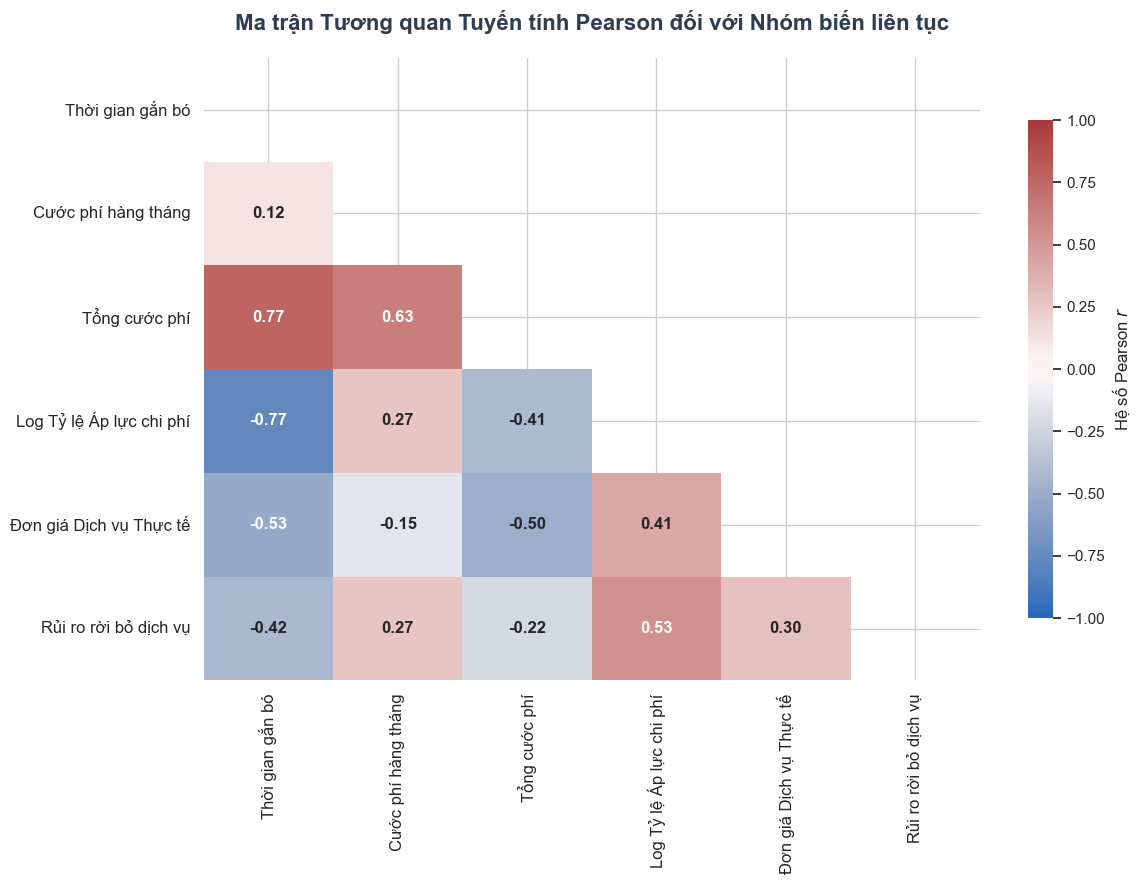

In [51]:
corr_pearson = df_train_copy[continuous_vars].corr(method='pearson')
corr_pearson = corr_pearson.rename(index=feature_mapping, columns=feature_mapping)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_pearson, 
    mask=np.triu(np.ones_like(corr_pearson, dtype=bool)), 
    cmap="vlag", 
    vmin=-1, vmax=1, center=0,
    annot=True, 
    fmt=".2f", 
    cbar_kws={"shrink": .8, "label": "Hệ số Pearson $r$"}, 
    annot_kws={"size": 12, "fontweight": "bold"}
)

plt.title('Ma trận Tương quan Tuyến tính Pearson đối với Nhóm biến liên tục', 
          fontsize=16, fontweight='bold', pad=20, color='#2C3E50')

plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét:**  
- `Log Tỷ lệ Áp lực chi phí` thể hiện năng lực khoanh vùng rủi ro xuất sắc với hệ số tương quan so với rủi ro rời bỏ dịch vụ đạt **$r$ = 0.53**, vượt trội hoàn toàn so với đặc trưng gốc `Cước phí hàng tháng` **$r$ = 0.27**, một lần nữa xác nhận khách hàng không rời bỏ dịch vụ vì cước phí cao mà là vì áp lực tài chính quá lớn so với thời gian gắn bó.
- `Đơn giá Dịch vụ Thực tế` ghi nhận mức tương quan đáng kể **$r$ = 0.30**, chứng minh việc phân tích cước phí trung bình trên từng dịch vụ cụ thể mang lại tín hiệu dự đoán rủi ro tốt hơn hẳn so với việc quan sát tổng hóa đơn.
- `Thời gian gắn bó` chứng minh vai trò thiết yếu trong việc giữ chân khách hàng với hệ số tương quan rất âm **$r$ = -0.42**. Vòng đời khách hàng càng dài, mức độ gắn bó với hệ sinh thái càng cao, tỷ lệ rời bỏ càng thấp.
- `Tổng cước phí` có độ trùng lặp thông tin **Multicollinearity** rất cao với `Thời gian gắn bó` **$r$ = 0.77**. So sánh dựa trên hệ số tương quan với biến mục tiêu gốc, `Tổng cước phí` chỉ đạt mức tương quan **$r$ = -0.22**, thấp hơn hẳn so với mức **-0.42** của `Thời gian gắn bó`. Vì vậy, ta thực hiện loại bỏ `Tổng cước phí` để giảm nhiễu.

**Note:** Áp dụng hệ số tương quan thứ bậc Spearman $\rho$ để biểu diễn cường độ và chiều hướng mối quan hệ đơn điệu **monotonic** giữa các biến đặc trưng rời rạc hóa nhằm sàng lọc đa cộng tuyến thứ bậc **Ordinal Multicollinearity Screening**, cũng như đánh giá năng lực dự đoán rủi ro **Predictive Power** của chúng so với các đặc trưng định tính gốc.

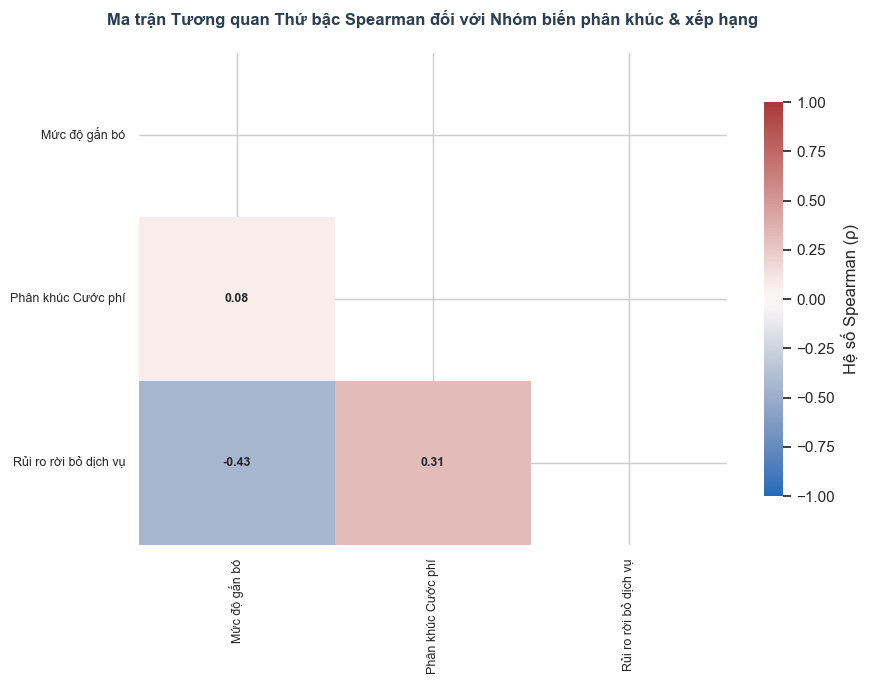

In [52]:

df_ordinal = df_train_copy[ordinal_vars].copy()

loyalty_mapping = {
    'Onboarding (0-6 tháng)': 1,
    'First Year (6-12 tháng)': 2,
    'Second Year (12-24 tháng)': 3,
    'Familiar (25-48 tháng)': 4,
    'Loyal (trên 48 tháng)': 5
}

charge_mapping = {
    'Budget (0-35$)': 1,
    'Standard (35-70$)': 2,
    'Premium (trên 70$)': 3
}

df_ordinal['loyalty_tier'] = df_ordinal['loyalty_tier'].map(loyalty_mapping)
df_ordinal['charge_segment'] = df_ordinal['charge_segment'].map(charge_mapping)

corr_spearman = df_ordinal.corr(method='spearman')
corr_spearman = corr_spearman.rename(index=feature_mapping, columns=feature_mapping)
mask_spearman = np.triu(np.ones_like(corr_spearman, dtype=bool))

plt.figure(figsize=(9, 7))

cmap_spearman = "vlag" 

sns.heatmap(
    corr_spearman, 
    mask=mask_spearman, 
    cmap=cmap_spearman, 
    vmin=-1, vmax=1, center=0,
    annot=True, 
    fmt=".2f", 
    cbar_kws={"shrink": .8, "label": "Hệ số Spearman (ρ)"}, 
    annot_kws={"size": 9, "fontweight": "bold"}
)

plt.title('Ma trận Tương quan Thứ bậc Spearman đối với Nhóm biến phân khúc & xếp hạng', 
          fontsize=12, fontweight='bold', pad=20, color='#2C3E50')

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Đặc trưng `Mức độ gắn bó` đạt mức tương quan nghịch **$\rho$ = -0.43**, nhỉnh hơn đôi chút so với đặc trưng định lượng gốc `Thời gian gắn bó` với **$r$ = -0.42**. Thao tác ép cụm **Binning** không chỉ bảo toàn lượng thông tin gốc mà còn xử lí các nhiễu loạn cục bộ của dữ liệu liên tục.
- `Phân khúc Cước phí` thể hiện sự vượt trội khi hệ số tương quan tăng vọt từ mức **$r$ = 0.27** của đặc trưng gốc `Cước phí hàng tháng` lên **$\rho$ = 0.31**. Điều này chứng minh rằng khách hàng không phản ứng tuyến tính theo cước hành tháng, mà là theo ngưỡng tâm lý. Việc phân khúc đã giúp mô hình tìm được ngưỡng này, qua đó nâng cao đáng kể khả năng khoanh vùng rủi ro.
- Ngoài ra, hệ số tương quan giữa hai biến độc lập `Phân khúc Khách hàng` và `Phân khúc Cước phí` ở mức cực kỳ thấp **$\rho$ = 0.08**, cho thấy chúng giải thích hai góc độ hoàn toàn độc lập về thời gian và tài chính, bổ trợ thông tin cho nhau một cách hiệu quả mà không gặp phải hiện tượng **Đa cộng tuyến**.

**Kết luận:**  
Dựa trên các hệ quy chiếu từ ma trận tương quan Pearson và Spearman, ta thực hiện các tinh chỉnh nhằm tối ưu hóa cấu trúc không gian vector đầu vào như sau
- Loại bỏ đặc trưng `Tổng cước phí` do mắc phải hiện tượng đa cộng tuyến **Multicollinearity** với `Thời gian gắn bó` khi hệ số tương quan đạt **0.77**. Đặc trưng này cũng mang tín hiệu dự đoán rủi ro **0.22**, yếu hơn so với `Thời gian gắn bó`. Việc giữ lại dải dữ liệu này có thể gây nhiễu trọng số mô hình tri thực hiện **Machine Learning**.
- Thay thế hai đặc trưng định lượng nguyên bản `Thời gian gắn bó` và `Cước phí hàng tháng` bởi các đặc trưng ép cụm tương ứng `Mức độ gắn bó` và `Phân khúc cước phí`, nhờ vào tính ưu việt đã được chứng minh thông qua hệ số tương quan **0.43** của `Mức độ gắn bó` so với **0.42** của `Thời gian gắn bó` và **0.31** của `Phân khúc Cước phí` so với **0.27** của `Cước phí hàng tháng`

### 5.4.2. Tương quan Nhóm Định tính & Điểm số (Categorical & Scoring Correlation)

**Note:** **Thư viện Pandas** không hỗ trợ công thức tính trực tiếp hệ số tương quan cho biến chữ **Categorical**. Nếu chỉ sử dụng công thức **Cramer's V** từ **kiểm định Chi-Square**, kết quả thường bị phóng đại khi dữ liệu có nhiều phân lớp. Hàm **cramers_v** đã được hiệu chỉnh thiên lệch, đảm bảo kết quả trả về từ **0** đến **1** phản ánh chính xác nhất mức độ tương quan giữa các đặc trưng.

In [53]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

**Note:** Với các biến phân loại nguyên bản, hệ thống điểm số **Scoring System** và siêu cờ **Composite Flags**, các thước đo tuyến tính hay thứ bậc tỏ ra kém hiệu quả. Để định lượng chính xác mức độ tương quan trong không gian này, ta áp dụng hệ số **Cramer's V** với $V \in [0, 1]$ được chuẩn hóa từ kiểm định **Chi-Bình phương** $\chi^2$. Ma trận này thực hiện 
- So sánh các đặc trưng gốc với các cờ rủi ro để so sánh độ nhạy tín hiệu dự đoán rủi ro.
- Đánh giá hiệu quả sự khoanh vùng rủi ro của Hệ thống điểm số tích lũy `Điểm Khiên bảo vệ`, `Điểm giải trí`.
- Tìm kiếm và phát hiện sự trùng lặp thông tin giữa các cụm cờ rủi ro.

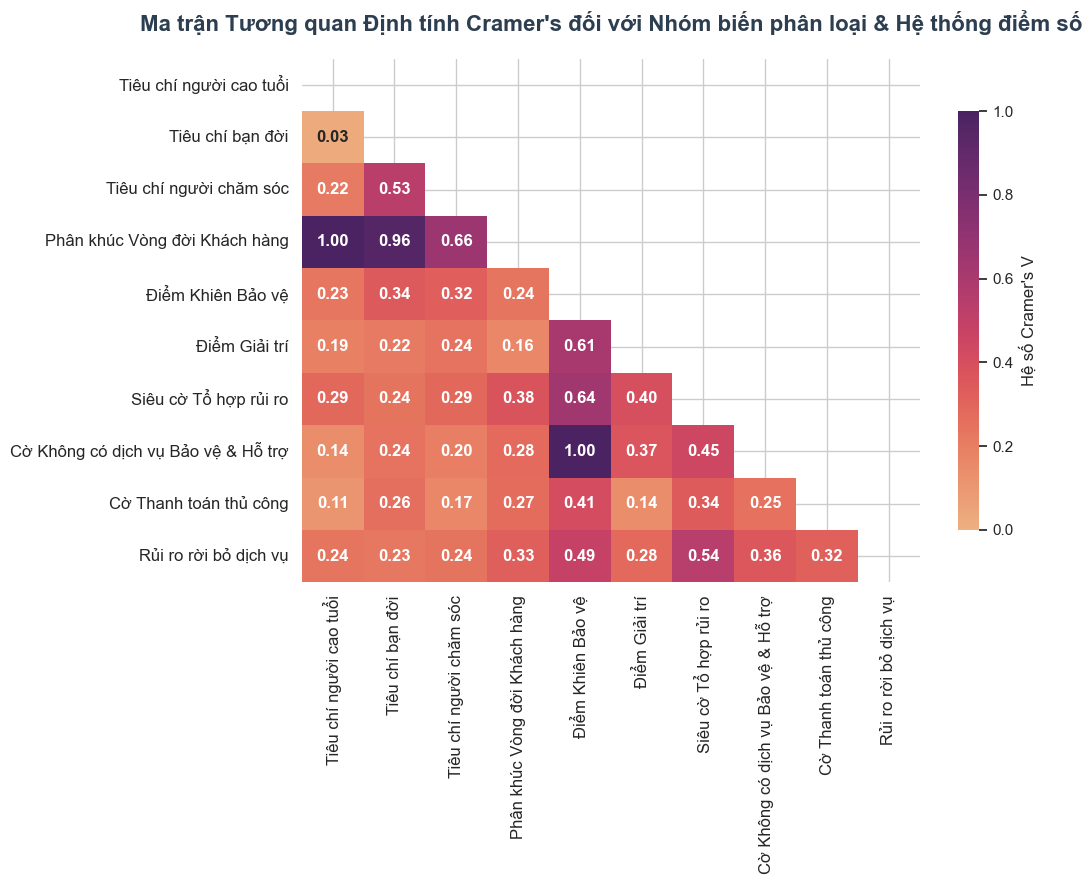

In [54]:
rows = []
for col1 in categorical_vars:
    col_vals = []
    for col2 in categorical_vars:
        val = cramers_v(df_train_copy[col1].astype(str), df_train_copy[col2].astype(str))
        col_vals.append(val)
    rows.append(col_vals)

corr_cramer = pd.DataFrame(rows, index=categorical_vars, columns=categorical_vars)
corr_cramer = corr_cramer.rename(index=feature_mapping, columns=feature_mapping)

mask_cramer = np.triu(np.ones_like(corr_cramer, dtype=bool))

plt.figure(figsize=(11, 9))

sns.heatmap(
    corr_cramer, 
    mask=mask_cramer, 
    cmap="flare", 
    vmin=0, vmax=1, 
    annot=True, 
    fmt=".2f", 
    cbar_kws={"shrink": .8, "label": "Hệ số Cramer's V"}, 
    annot_kws={"size": 12, "fontweight": "bold"}
)

plt.title("Ma trận Tương quan Định tính Cramer's đối với Nhóm biến phân loại & Hệ thống điểm số", 
          fontsize=16, fontweight='bold', pad=20, color='#2C3E50')

plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

**Nhận xét:**
- `Siêu cờ Tổ hợp rủi ro` thể hiện năng lực khoanh vùng rủi ro vô cùng vượt trội với hệ số tương quan đạt **$V$ = 0.54**. Điều này khẳng định việc kết hợp các tín hiệu rủi ro đơn lẻ *Cáp quang* + *Hợp đồng ngắn hạn* thành một tổ hợp là một thao tác **Feature Engineering** đúng đắn. Trong khi đó `Cờ Thanh toán thủ công` duy trì mức tín hiệu dự đoán tốt với $V = 0.32$, khẳng định phương thức thanh toán ảnh hưởng rõ rệt đến rủi ro rời bỏ dịch vụ  
- `Điểm Khiên Bảo vệ` thể hiện vai trò dự đoán rủi ro tốt khi mức tương quan với rủi ro rời bỏ dịch vụ đạt **$V$ = 0.49**. Trong khi đó, `Điểm Giải trí` ghi nhận mức tương quan trung bình **$V$ = 0.28**. Sự chênh lệch này hoàn toàn phù hợp với phân tích trước đó rằng các dịch vụ bảo mật, hỗ trợ đóng vai trò chủ yếu trong việc giữ chân khách hàng trong khi dịch vụ giải trí ít tạo ra sức ảnh hưởng trong việc đưa ra quyết định của khách hàng. Ta quyết định giữ lại hai hệ thống điểm số này để phục vụ mô hình **Cây phân nhánh**.
- Đặc trưng nén `Phân khúc Vòng đời Khách hàng` tương quan gần như tuyệt đối với các đặc trưng cấu thành nó gồm `Tiêu chí người cao tuổi` với mức tương quan hoàn hảo **1.00** và `Tiêu chí bạn đời` cùng hệ số **0.96**. Tuy nhiên, khả năng khoanh vùng rủi ro của biến nén đã được chứng minh là ưu việt hơn so với các đặc trưng gốc, với hệ số tương quan lần lượt là **$V$=0.33** so với  **$V$=0.24** và **$V$=0.23**. Do đó, ta thực hiện loại bỏ các đặc trưng nhân khẩu học gốc ra khỏi không gian vector để triệt tiêu nhiễu.
- `Cờ Không có dịch vụ Bảo vệ & Hỗ trợ` và `Điểm Khiên Bảo vệ` gặp phải hiện tượng Đa cộng tuyến hoàn hảo **$V$ = 1.00** vì về bản chất, cờ rủi ro chỉ là một bản tóm tắt **subset** của điểm số. Dù vậy, `Điểm Khiên Bảo vệ` với hệ số tương quan **$V$ = 0.49** chứa lượng thông tin hữu ích hơn hẳn so với Cờ **0.36**. Áp dụng nguyên tắc bảo toàn đặc trưng mạnh, ta chỉ giữ lại `Điểm Khiên Bảo vệ` và loại bỏ Cờ để tránh bẫy biến giả **Dummy Variable Trap**.

**Kết luận:** Thông qua ma trận hệ số Cramer's V, kiến trúc dữ liệu đầu vào cho nhóm biến phân loại được hoàn thiện sau các tinh chỉnh nhằm ưu tiên những đặc trưng mới mang khả năng khoanh vùng rủi ro mạnh mẽ gồm: `Siêu cờ Tổ hợp rủi ro`, `Điểm Khiên Bảo vệ`, `Điểm Giải trí`, `Cờ Thanh toán thủ công` và `Phân khúc Vòng đời Khách hàng`; cùng lúc đó thực hiện loại bỏ nhóm biến nhân khẩu học phân mảnh `Tiêu chí người cao tuổi`, `Tiêu chí bạn đời`, `Tiêu chí người chăm sóc` và cờ rủi ro `Cờ Không có dịch vụ Bảo vệ & Hỗ trợ` nhằm ngăn chặn rủi ro từ bẫy đa cộng tuyến định tính **Dummy Variable Trap**.

### 5.4.3. Tổng kết: Bảng Xếp hạng Sức mạnh Đặc trưng (Feature Superiority Ranking)

**Note:** Thực hiện tổng hợp hệ số tương quan theo các phương pháp thống kê Pearson, Spearman, Cramer's V dưới dạng giá trị tuyệt đối nhằm thiết lập một thang đo chung từ **0** đến **1** về khả năng khoanh vùng rủi ro rời bỏ dịch vụ. Bảng xếp hạng này tổng hợp phần **5.4 Phân tích Tương quan Toàn cục (Global Correlation Analysis)** thông qua việc trực quan hóa sự áp đảo về mật độ thông tin của các siêu cờ, biến nén và hệ thống phân khúc mới tạo so với nhóm đặc trưng nguyên bản.

In [55]:
target_name = 'Rủi ro rời bỏ dịch vụ'

pearson_strength = corr_pearson[target_name].drop(target_name).abs()
spearman_strength = corr_spearman[target_name].drop(target_name).abs()
cramer_strength = corr_cramer[target_name].drop(target_name).abs()

all_features_strength = pd.concat([pearson_strength, spearman_strength, cramer_strength])
all_features_strength = all_features_strength.groupby(all_features_strength.index).max()
all_features_strength = all_features_strength.sort_values(ascending=False)

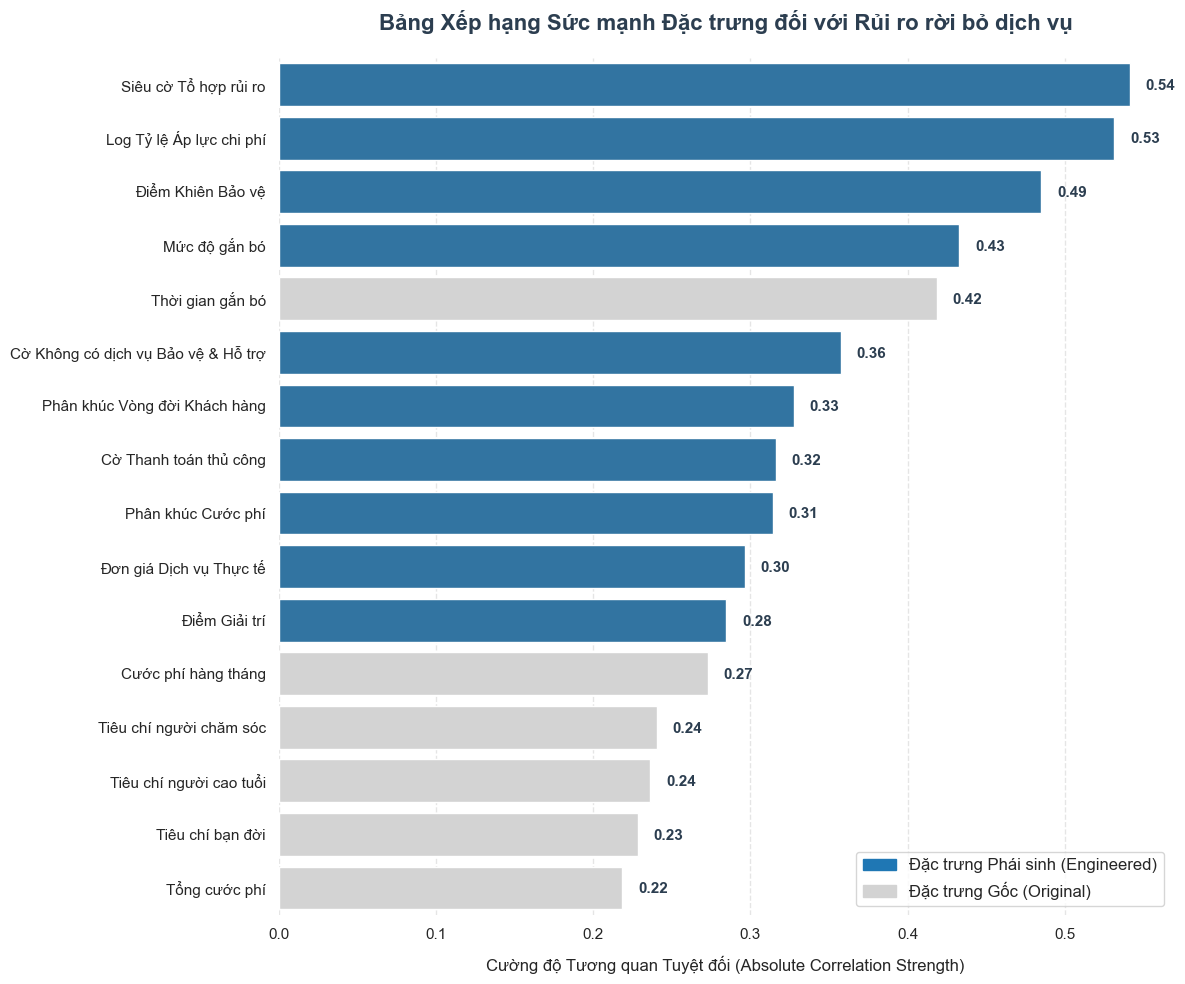

In [56]:
engineered_cols_df = [
    'composite_risk_profile', 
    'charge_to_tenure_ratio_log', 
    'security_score', 
    'loyalty_tier', 
    'zero_supportive_service', 
    'demographic_profile', 
    'manual_payment', 
    'charge_segment', 
    'average_cost_per_service', 
    'streaming_score'
]

plt.figure(figsize=(12, 10))
engineered_display_names = [feature_mapping.get(col, col) for col in engineered_cols_df]
display_names = [feature_mapping.get(col, col) for col in all_features_strength.index]

colors = ['#1f77b4' if name in engineered_display_names else '#d3d3d3' for name in display_names]

ax = sns.barplot(
    x=all_features_strength.values, 
    y=display_names, 
    hue=display_names,
    palette=colors,
    legend=False
)

plt.title('Bảng Xếp hạng Sức mạnh Đặc trưng đối với Rủi ro rời bỏ dịch vụ', 
          fontsize=16, fontweight='bold', pad=20, color='#2C3E50') 
plt.xlabel('Cường độ Tương quan Tuyệt đối (Absolute Correlation Strength)', fontsize=12, labelpad=10)
plt.ylabel('')

for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.1, '{:1.2f}'.format(width), 
             ha="left", color='#2C3E50', fontweight='bold', fontsize=11)

blue_patch = mpatches.Patch(color='#1f77b4', label='Đặc trưng Phái sinh (Engineered)')
gray_patch = mpatches.Patch(color='#d3d3d3', label='Đặc trưng Gốc (Original)')
plt.legend(handles=[blue_patch, gray_patch], loc='lower right', fontsize=12, frameon=True)

# Làm sạch đồ thị (Đã xóa hoàn toàn đường gạch đỏ 0.3)
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Nhận xét:**  
- Bảng xếp hạng cường độ tương quan tuyệt đối đã trực quan hóa sự áp đảo hoàn toàn của nhóm đặc trưng phái sinh **Engineered Features** so với dải dữ liệu nguyên bản **Original Features**. Thay vì áp đặt một ngưỡng cắt bỏ số liệu thiếu cơ sở, không gian vector được đánh giá dựa trên sức mạnh tương đối và khả năng đóng góp độc lập vào mô hình
    - Các vị trí đầu tiên đều thuộc về các đặc trưng được tinh chế sâu như `Siêu cờ Tổ hợp rủi ro` **0.54**, `Log Tỷ lệ Áp lực chi phí` **0.53** và `Điểm Khiên Bảo vệ` **0.49**, nhận diện chính xác các điểm gãy khiến khách hàng rời bỏ dịch vụ bao gồm sự nhạy cảm về giá của nhóm dùng cáp quang mang hợp đồng ngắn hạn, áp lực tài chính tích lũy theo thời gian và sự hạn chế tiếp cận các dịch vụ hỗ trợ và bảo vệ.
    - Đặc trưng phái sinh Mức độ gắn bó **0.43** vượt qua đặc trưng định lượng gốc `Thời gian gắn bó` **0.42**. Thao tác ép cụm **Binning** thành công loại bỏ các nhiễu loạn cục bộ của dải số liên tục, thiết lập ranh giới rủi ro rõ ràng hơn nhằm chuẩn bị cho cơ chế cắt nhánh **split-points** của thuật toán dạng Cây.
    - `Phân khúc Vòng đời Khách hàng` **0.33** bỏ xa các đặc trưng gốc rải rác cấu thành nên nó, có thể kể đến như `Tiêu chí người chăm sóc` hay `Tiêu chí người cao tuổi` với cùng mức **0.24**. Tương tự, `Phân khúc Cước phí` **0.31** cũng tối ưu hóa tín hiệu dự báo tốt hơn hẳn `Cước phí hàng tháng` **0.27**.
    - Dù `Đơn giá Dịch vụ Thực tế` với mức tương quan **0.30** và `Điểm Giải trí` với **0.28** có hệ số đơn lẻ thấp hơn, ta vẫn giữ lại hai đặc trưng này. Các thuật toán **Boosting** mạnh như **XGBoost**/**LightGBM** hoàn toàn có năng lực phối hợp các tín hiệu tầm trung với các đặc trưng chủ lực được đề cập trước đó nhằm tạo ra các quy tắc quyết định **Decision Rules** phức tạp ở các tầng cây sâu hơn.
    - `Cờ Không có dịch vụ Bảo vệ & Hỗ trợ` **0.36** dù có điểm số cao nhưng do trùng lặp thông tin hoàn hảo với `Điểm Khiên Bảo vệ` **0.49** nên vẫn sẽ bị loại bỏ cùng các đặc trưng gốc mang màu xám.

**Kết luận:** Không gian đặc trưng sau quá trình thực nghiệm được cô đọng thành bộ **9** đặc trưng tối ưu nhất, đảm bảo tính độc lập tối đa giữa các vector đầu vào, mang lại hiệu suất cao nhất cho **Modeling Pipeline** mà không lo rủi ro **Overfitting**.

## 5.5: Lựa chọn và Thanh lọc Đặc trưng (Feature Selection)

**Note:** Dựa trên dữ liệu từ Bảng Xếp hạng Sức mạnh Đặc trưng **Feature Superiority Ranking** và đặc thù của các thuật toán **Gradient Boosting** **LightGBM**, **XGBoost**, không gian vector đầu vào được xây dựng theo 2 nguyên tắc
- **Winner-takes-all**: Khi phát hiện các cụm biến mang thông tin trùng lặp, giữ lại duy nhất đặc trưng có năng lực phân tách mạnh nhất, dứt khoát loại bỏ các biến đồng dạng như bản sao nhị phân hay các đặc trưng có tương quan tuyến tính cao để tối ưu hóa không gian đa chiều.
- **Noise Removal**: Thực hiện lược bỏ các đặc trưng gốc khi chúng đã được cấu trúc hóa thành dạng phái sinh hoặc rời rạc hóa **Discretized**. Quá trình này giúp chuẩn hóa dữ liệu, buộc mô hình tập trung khai thác các ranh giới phân tách rủi ro tuyến tính đã được làm sạch nhiễu.

### 5.5.1. Danh sách Đặc trưng Ưu việt (Core Features)

Danh sách chứa các đặc trưng mang mật độ thông tin cao nhất, được tối ưu hóa hoàn toàn để tạo ra các điểm phân ngưỡng **split-points** tối ưu cho mô hình cây
- `Nhóm ưu việt` **Top-tier** với `Siêu cờ Tổ hợp rủi ro`, `Log Tỷ lệ Áp lực chi phí`, `Điểm Khiên Bảo vệ` – Những đặc trưng có năng lực khoanh vùng rủi ro tốt nhất, có thể đặt ở vị trí gốc **Root nodes** của cây quyết định.
- `Nhóm Rời rạc hóa & Gom cụm đặc trưng` **Binning/Grouping** có thể kể đến `Mức độ gắn bó`, `Phân khúc Vòng đời Khách hàng`, `Phân khúc Cước phí` – Đại diện cho nhóm đặc trưng gốc đã được loại bỏ để khử nhiễu.
- `Nhóm Hỗ trợ` **Mid-tier** gồm `Cờ Thanh toán thủ công`, `Đơn giá Dịch vụ Thực tế` và `Điểm Giải trí` – cung cấp các tín hiệu phi tuyến tính quan trọng khi cây phát triển xuống các tầng sâu hơn.

### 5.5.2. Danh sách Đặc trưng Loại bỏ (Dropped Features)

Để tối ưu hóa không gian vector đầu vào và ngăn ngừa hiện tượng quá khớp **Overfitting**, các nhóm đặc trưng sau bị loại bỏ khỏi mô hình:
- Nhóm Đa cộng tuyến nghiêm trọng **Multicollinearity**: *Tổng cước phí* `TotalCharges` và *Cờ Không có dịch vụ Bảo vệ & Hỗ trợ* `zero_supportive_service`. Các biến này mang thông tin trùng lặp lớn, dễ gây sai lệch hệ số hồi quy.
- Nhóm Bị thay thế/Nén thông tin **Redundant**: *Thời gian gắn bó* `tenure`,*Cước phí hàng tháng* `MonthlyCharges`, cùng các tiêu chí về *Người cao tuổi*, *Bạn đời*, và *Người chăm sóc*. Các đặc trưng gốc này đã được khái quát hóa hoặc rời rạc hóa.
- Nhóm Nhiễu hệ thống **Zero-Signal**: *Giới tính* `gender` và *Tỷ lệ sốc cước* `bill_shock_ratio`. Đây là các biến không mang lại giá trị phân tách, chứa tỷ lệ nhiễu cao, không có khả năng đóng góp vào việc hỗ trợ dự báo.

### 5.5.3. Thực thi Thanh lọc & Đóng gói Schema (Execution & Packaging)

In [57]:
COLS_TO_DROP = [
    'id',                       # Mã định danh, không có giá trị dự báo
    'gender',                   # Tín hiệu phân tách rủi ro quá yếu (Zero-Signal)
    'TotalCharges',             # Nhiễu, đa cộng tuyến nghiêm trọng với tenure
    'tenure',                   # Đã bị thay thế bởi biến phân khúc 'loyalty_tier'
    'MonthlyCharges',           # Đã bị thay thế bởi biến phân khúc 'charge_segment'
    'SeniorCitizen',            # Đã bị nén vào 'demographic_profile'
    'Partner',                  # Đã bị nén vào 'demographic_profile'
    'Dependents',               # Đã bị nén vào 'demographic_profile'
    'bill_shock_ratio',         # Tín hiệu phân tách rủi ro bị vô hiệu hóa thực tế
    'zero_supportive_service',  # Đa cộng tuyến hoàn hảo (1.00) với 'security_score'
    'Churn'                     # Bỏ nhãn dạng chữ (Yes/No), giữ lại 'churn_flag' dạng số (1/0)
]

df_final_selected = df_train_copy.drop(columns=COLS_TO_DROP)

print("CÁC ĐẶC TRƯNG TỐI ƯU PHỤC VỤ MACHINE LEARNING\n")
print("-" * 50)
print(f"Số lượng đặc trưng ban đầu: {df_train_copy.shape[1]}")
print(f"Số lượng đặc trưng loại bỏ: {len(COLS_TO_DROP)}")
print(f"Không gian vector tối ưu (Final Space): {df_final_selected.shape[1]} đặc trưng, bao gồm cả mục tiêu\n")

CÁC ĐẶC TRƯNG TỐI ƯU PHỤC VỤ MACHINE LEARNING

--------------------------------------------------
Số lượng đặc trưng ban đầu: 34
Số lượng đặc trưng loại bỏ: 11
Không gian vector tối ưu (Final Space): 23 đặc trưng, bao gồm cả mục tiêu



**CÁC ĐẶC TRƯNG TỐI ƯU PHỤC VỤ MACHINE LEARNING**

| Đặc trưng | Kiểu đặc trưng | Mô tả | Ghi chú |
| :--- | :--- | :--- | :--- |
| `PhoneService` | Gốc | Dịch vụ điện thoại | **Yes** / **No** |
| `MultipleLines` | Gốc | Dùng nhiều số điện thoại | **Yes** / **No** / **No phone service** |
| `InternetService` | Gốc | Loại mạng Internet | **DSL** / **Fiber optic** / **No** |
| `OnlineSecurity` | Gốc | Gói bảo mật trực tuyến | **Yes** / **No** / **No internet service** |
| `OnlineBackup` | Gốc | Gói sao lưu đám mây | **Yes** / **No** / **No internet service** |
| `DeviceProtection` | Gốc | Gói bảo vệ thiết bị | **Yes** / **No** / **No internet service** |
| `TechSupport` | Gốc | Gói hỗ trợ kỹ thuật | **Yes** / **No** / **No internet service** |
| `StreamingTV` | Gốc | Xem truyền hình qua mạng | **Yes** / **No** / **No internet service** |
| `StreamingMovies` | Gốc | Xem phim trực tuyến | **Yes** / **No** / **No internet service** |
| `Contract` | Gốc | Loại hợp đồng | **Month-to-month** / **One year** / **Two year** |
| `PaperlessBilling` | Gốc | Hóa đơn điện tử | **Yes** / **No** |
| `PaymentMethod` | Gốc | Phương thức thanh toán | **Electronic check** / **Mailed check** / **Bank transfer (automatic)** / **Credit card (automatic)** |
| `churn_flag` | Mục tiêu | Trạng thái rời bỏ (nhị phân) | `Churn` là **Yes** gán **1**, **No** gán **0** |
| `loyalty_tier` | Phái sinh — Phân khúc | Phân khúc trung thành | Dùng `pd.cut` chia bins `[0, 6, 12, 24, 48, vô cùng]` tương ứng với các nhãn: **Onboarding** / **First Year** / **Second Year** / **Familiar** / **Loyal** |
| `charge_segment` | Phái sinh — Phân khúc | Phân khúc cước phí | Dùng `pd.cut` chia bins `[0, 35, 70, vô cùng]` tương ứng với các nhãn: **Budget** / **Standard** / **Premium** |
| `total_active_services` | Phái sinh — Đếm | Tổng số dịch vụ đang dùng | Đếm tổng số lượng nhãn **Yes** của các dịch vụ. Riêng `InternetService` nếu là **DSL** hoặc **Fiber optic** thì đếm là 1, gồm `InternetService`, `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`, `StreamingTV`, `StreamingMovies`, `PhoneService`, `MultipleLines`  |
| `charge_to_tenure_ratio_log` | Phái sinh — Tài chính | Log tỷ lệ áp lực chi phí | Công thức: np.log1p(`MonthlyCharges` / `tenure`) |
| `average_cost_per_service` | Phái sinh — Tài chính | Đơn giá trung bình mỗi dịch vụ | Công thức: `MonthlyCharges` / `total_active_services` |
| `security_score` | Phái sinh — Điểm số | Điểm Khiên Bảo vệ đo lường số lớp phòng thủ kỹ thuật | Đếm tổng số lượng nhãn **Yes** của 4 biến: `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection` (Thang điểm 0-4). Quan trọng: Nếu `InternetService` là **No** thì gán đè thành **-1** |
| `streaming_score` | Phái sinh — Điểm số | Điểm Giải trí đo lường mức độ sử dụng truyền thông | Đếm tổng số lượng nhãn **Yes** của 2 biến: `StreamingTV`, `StreamingMovies` (Thang điểm 0-2). Quan trọng: Nếu `InternetService` là **No** thì gán đè thành **-1** |
| `manual_payment` | Phái sinh — Cờ | Khách hàng thanh toán bằng phương thức thủ công | Nếu `PaymentMethod` là **Electronic check** hoặc **Mailed check** gán **1**, các phương thức còn lại gán **0** |
| `composite_risk_profile` | Phái sinh — Siêu cờ | Tổ hợp rủi ro rời bỏ ở mức đỉnh điểm | Nếu `Contract` là **Month-to-month** ĐỒNG THỜI `InternetService` là **Fiber optic** gán **1**, các trường hợp khác gán **0** |
| `demographic_profile` | Phái sinh — Biến nén | Phân khúc nhân khẩu học tổng hợp đa biến | Nhóm **Isolated Senior**: `SeniorCitizen`=**1** VÀ `Partner`=**No** VÀ `Dependents`=**No** <br> Nhóm **Supported Senior**: `SeniorCitizen`=**1** VÀ (`Partner`=**Yes** HOẶC `Dependents`=**Yes**) <br> Nhóm **Single Youth**: `SeniorCitizen`=**0** VÀ `Partner`=**No** VÀ `Dependents`=**No** <br> Nhóm **Nuclear Family**: `SeniorCitizen`=**0** VÀ (`Partner`=**Yes** HOẶC `Dependents`=**Yes**) |

# 6. Tổng kết & Chuyển giao hệ thống MLOps (Pipeline Handover)

**Note:**  
Notebook này tập trung hoàn thành trọn vẹn vai trò của giai đoạn **Khám phá Dữ liệu (EDA) và Phác thảo Sơ đồ Đặc trưng**. Nhằm tuân thủ cấu trúc thiết kế modular trong môi trường Production, các bước thực thi kỹ thuật tiếp theo như chia tập kiểm thử **Validation Split** hay mã hóa biến phân loại **Categorical Encoding** sẽ không được gọi rời rạc tại đây. Thay vào đó, chúng được quản lý tập trung và đồng bộ trong module tiền xử lý `data_transformation.py` và huấn luyện `model_trainer.py` của hệ thống Pipeline. Cơ chế vận hành được thiết kế đồng nhất như sau:
* **Chiến lược Mã hóa Biến Categorical & Binary:** Để chuyển đổi không gian đặc trưng về dạng số học, hệ thống Pipeline sử dụng công cụ `ColumnTransformer` để áp dụng các lớp xử lý chuyên biệt cho từng nhóm cột. Nhóm biến phân loại nhiều lớp và nhị phân sẽ đi qua bộ lọc giá trị khuyết thiếu `SimpleImputer(strategy='most_frequent')` và mã hóa tự động bằng `OneHotEncoder(drop='first', handle_unknown='ignore')`. Cơ chế này vừa triệt tiêu bẫy biến giả **Dummy Variable Trap**, vừa bảo toàn tính tổng quát khi mô hình đối mặt với các nhãn lạ ở tập Test.
* **Kiểm soát Tuyệt đối Hiện tượng Rò rỉ Dữ liệu (Data Leakage):** Preprocessing Pipeline được thiết lập để chỉ gọi lệnh `fit_transform` độc quyền trên tập dữ liệu Train nhằm học các ngưỡng cắt ngoại lai **Winsorization** và trọng số chuẩn hóa. Tập dữ liệu Test sau đó chỉ đi qua lệnh `transform`. Kỹ thuật cân bằng nhãn bằng thuật toán **SMOTE** cũng chỉ được kích hoạt phía sau bước biến đổi này trên tập huấn luyện, giữ cho phân phối của tập Test hoàn toàn nguyên bản.
* **Khung Xác thực Chéo & Đánh giá (Cross-Validation Strategy):** Tại module `model_trainer.py`, tập dữ liệu sẽ được phân tách thông qua hàm `train_test_split` có cấu hình `stratify` nhằm giữ nguyên tỷ lệ phân phối nhãn của biến mục tiêu `churn_flag`. Quá trình tối ưu hóa siêu tham số cho hai thuật toán **LightGBM** và **XGBoost** sẽ được thực hiện thông qua cơ chế xác thực chéo **3-fold Cross-Validation** với metric scoring chủ đạo là `roc_auc`.
* Sự phân định rạch ròi giữa phân tích chiến lược **EDA Notebook** và vận hành thực thi **ML Pipeline** đảm bảo bộ mã nguồn đạt tính tối giản, tường minh và sẵn sàng bàn giao cho nhóm xây dựng pipeline.